In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from pathlib import Path
import joblib, json, time

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
sns.set_theme()


In [4]:
RAW_CSV = r"..\data\raw\eCommerce_Customer_support_data.csv"   # adjust to your layout
ARTIFACTS_DIR = r"..\artifacts"
PREPROCESS_DIR = rf"{ARTIFACTS_DIR}\preprocess"
MODELS_DIR = rf"{ARTIFACTS_DIR}\models"


In [7]:
import os
for d in (ARTIFACTS_DIR, PREPROCESS_DIR, MODELS_DIR):
    os.makedirs(d, exist_ok=True)


In [5]:
data = pd.read_csv(RAW_CSV)
data.shape

(85907, 20)

In [6]:
data.head()

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


In [103]:
# Business Problem Analysis
print("=== BUSINESS PROBLEM ANALYSIS ===")
print("Objective: Predict Customer Satisfaction (CSAT) scores for eCommerce support interactions")
print("Business Value: Improve customer experience and operational efficiency")
print("Success Metrics: Model accuracy, interpretability, actionable insights")

# Dataset Overview
print(f"\n=== DATASET OVERVIEW ===")
print(f"Total records: {data.shape[0]:,}")
print(f"Features: {data.shape[1]}")
print(f"Target variable: CSAT Score (1-5 scale)")
print(f"Date range: {data['Issue_reported at'].min()} to {data['Issue_reported at'].max()}")


=== BUSINESS PROBLEM ANALYSIS ===
Objective: Predict Customer Satisfaction (CSAT) scores for eCommerce support interactions
Business Value: Improve customer experience and operational efficiency
Success Metrics: Model accuracy, interpretability, actionable insights

=== DATASET OVERVIEW ===
Total records: 85,907
Features: 20
Target variable: CSAT Score (1-5 scale)
Date range: 01/08/2023 00:00 to 31/08/2023 23:58


In [7]:
# Data Quality Report
def data_quality_report(df):
    quality_report = pd.DataFrame({
        'Feature': df.columns,
        'Data_Type': df.dtypes,
        'Missing_Count': df.isnull().sum(),
        'Missing_Percentage': (df.isnull().sum() / len(df)) * 100,
        'Unique_Values': df.nunique(),
        'Memory_Usage': df.memory_usage(deep=True,index = False)
    })
    
    quality_report['Missing_Percentage'] = quality_report['Missing_Percentage'].round(2)
    return quality_report.sort_values('Missing_Percentage', ascending=False)

quality_report = data_quality_report(data)
print("=== DATA QUALITY REPORT ===")
print(quality_report)


=== DATA QUALITY REPORT ===
                                         Feature Data_Type  Missing_Count  \
connected_handling_time  connected_handling_time   float64          85665   
Customer_City                      Customer_City    object          68828   
Product_category                Product_category    object          68711   
Item_price                            Item_price   float64          68701   
order_date_time                  order_date_time    object          68693   
Customer Remarks                Customer Remarks    object          57165   
Order_id                                Order_id    object          18232   
Unique id                              Unique id    object              0   
Sub-category                        Sub-category    object              0   
category                                category    object              0   
channel_name                        channel_name    object              0   
Issue_reported at              Issue_reported at

In [8]:
data.shape

(85907, 20)

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                85907 non-null  object 
 1   channel_name             85907 non-null  object 
 2   category                 85907 non-null  object 
 3   Sub-category             85907 non-null  object 
 4   Customer Remarks         28742 non-null  object 
 5   Order_id                 67675 non-null  object 
 6   order_date_time          17214 non-null  object 
 7   Issue_reported at        85907 non-null  object 
 8   issue_responded          85907 non-null  object 
 9   Survey_response_Date     85907 non-null  object 
 10  Customer_City            17079 non-null  object 
 11  Product_category         17196 non-null  object 
 12  Item_price               17206 non-null  float64
 13  connected_handling_time  242 non-null    float64
 14  Agent_name            

In [10]:
data.describe()

,Item_price,connected_handling_time,CSAT Score
count,17206.000000,242.000000,85907.000000
mean,5660.774846,462.400826,4.242157
std,12825.728411,246.295037,1.378903
min,0.000000,0.000000,1.000000
25%,392.000000,293.000000,4.000000
50%,979.000000,427.000000,5.000000
75%,2699.750000,592.250000,5.000000
max,164999.000000,1986.000000,5.000000


In [11]:
# show all features of data irrespective of their number
pd.set_option('display.max_columns', None)

In [12]:
data.isnull().sum()

Unique id                      0
channel_name                   0
category                       0
Sub-category                   0
Customer Remarks           57165
Order_id                   18232
order_date_time            68693
Issue_reported at              0
issue_responded                0
Survey_response_Date           0
Customer_City              68828
Product_category           68711
Item_price                 68701
connected_handling_time    85665
Agent_name                     0
Supervisor                     0
Manager                        0
Tenure Bucket                  0
Agent Shift                    0
CSAT Score                     0
dtype: int64

Features with missing values are Customer Remarks , Order_id, order_date_time, Customer_City, Product_category, Item_price, connected_handling_time        

In [13]:
data.nunique()

Unique id                  85907
channel_name                   3
category                      12
Sub-category                  57
Customer Remarks           18231
Order_id                   67675
order_date_time            13766
Issue_reported at          30923
issue_responded            30262
Survey_response_Date          31
Customer_City               1782
Product_category               9
Item_price                  2789
connected_handling_time      211
Agent_name                  1371
Supervisor                    40
Manager                        6
Tenure Bucket                  5
Agent Shift                    5
CSAT Score                     5
dtype: int64

In [111]:
# Order_id column check.Whether there are duplication in this column . If yes , it would mean that more than one record corresponding to a single order resolution.
print(data['Order_id'].duplicated().sum())
# The number of duplication entries coming are equal to the number of null values in the column . Could this be referring nan values in the column as duplicates ?
all_order_id = data['Order_id'].dropna()
print(all_order_id.duplicated().sum())
# It was indeed referring to the NaN values in the column as duplicates.
# Other than that, there are no duplicate entries in the Order_id column.
# This mean order id is also a unique record idenfier column for this dataset.
# We will be dropping this column.


18231
0


In [112]:
sum(data.duplicated())

0

In [14]:
data.drop(["Unique id" , "Order_id"],axis = 1 , inplace = True)

In [114]:
data.columns

Index(['channel_name', 'category', 'Sub-category', 'Customer Remarks',
       'order_date_time', 'Issue_reported at', 'issue_responded',
       'Survey_response_Date', 'Customer_City', 'Product_category',
       'Item_price', 'connected_handling_time', 'Agent_name', 'Supervisor',
       'Manager', 'Tenure Bucket', 'Agent Shift', 'CSAT Score'],
      dtype='object')

In [115]:
# channel_name column analysis and preprocessing

data['channel_name'].isna().sum()

np.int64(0)

Basic Frequency Analysis

Channel Distribution:
Counts:
channel_name
Inbound    68142
Outcall    14742
Email       3023
Name: count, dtype: int64
Proportions:
channel_name
Inbound    0.793207
Outcall    0.171604
Email      0.035189
Name: proportion, dtype: float64


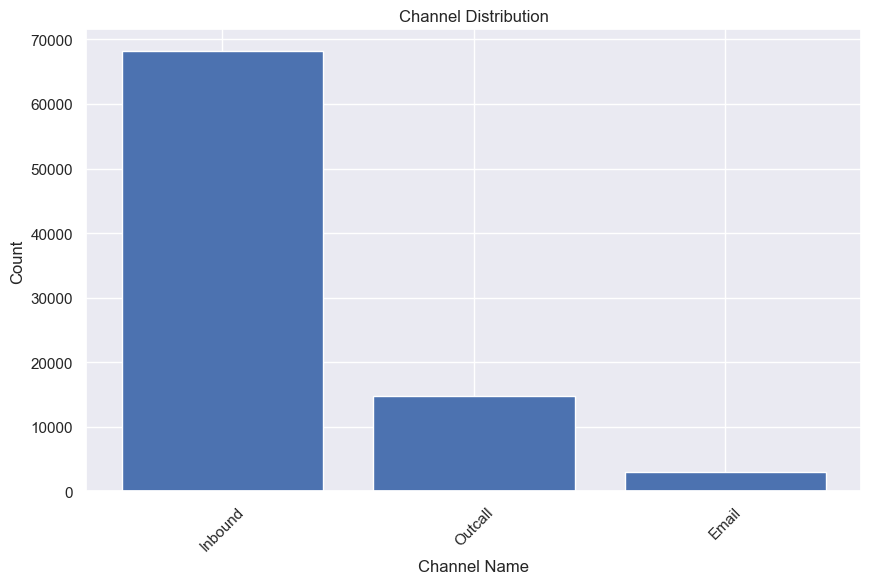

In [116]:
# Get value counts and proportions
channel_counts = data['channel_name'].value_counts()
channel_proportions = data['channel_name'].value_counts(normalize=True)

print("Channel Distribution:")
print(f"Counts:\n{channel_counts}")
print(f"Proportions:\n{channel_proportions}")


# 3 categories in the channel_name column namely Inbound , Outcall and Email.
# Inbound refers to the incoming customer interactions, Outcall refers to the outgoing interactions initiated by the support team, and Email refers to the interactions that happen over email.

# Code to visualize the channel distribution
plt.figure(figsize=(10, 6))
plt.bar(channel_counts.index, channel_counts.values)
plt.title("Channel Distribution")
plt.xlabel("Channel Name")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

Channel-Csat relationship Analysis

In [117]:
# Cross-tabulation analysis
channel_csat_crosstab = pd.crosstab(data['channel_name'], data['CSAT Score'])
print("Channel vs CSAT Score Cross-tabulation:")
print(channel_csat_crosstab)

# Calculate CSAT statistics by channel
channel_csat_stats = data.groupby('channel_name')['CSAT Score'].agg(['mean', 'std', 'count'])
print("CSAT Statistics by Channel:")
print(channel_csat_stats)


Channel vs CSAT Score Cross-tabulation:
CSAT Score       1     2     3     4      5
channel_name                               
Email          636    64   102   388   1833
Inbound       8745  1011  2033  8934  47419
Outcall       1849   208   423  1897  10365
CSAT Statistics by Channel:
                  mean       std  count
channel_name                           
Email         3.899107  1.615222   3023
Inbound       4.251372  1.370008  68142
Outcall       4.269909  1.358055  14742


In [118]:
from scipy.stats import chi2_contingency, f_oneway

# Chi-square test for independence
chi2, p_value, dof, expected = chi2_contingency(channel_csat_crosstab)
print(f"Chi-square test p-value: {p_value}")

# ANOVA test for mean differences across channels
channel_groups = [data[data['channel_name'] == channel]['CSAT Score']
                  for channel in data['channel_name'].unique()]
f_stat, anova_p = f_oneway(*channel_groups)
print(f"ANOVA test p-value: {anova_p}")


Chi-square test p-value: 6.669001520780051e-39
ANOVA test p-value: 2.3194399795949356e-43


chi2 pval < 0.05 , therefore Null Hypothesis failed :
Based on the Chi square test of independence , there is significant relationship between the channel_name and the csat_score.

anova pval < 0.05 , therefore :
Based on the One way anova test ,the mean of the csat score for atleast one of the channels in significantly different from other channel_name.

In [119]:
# One-hot encoding for channel_name
channel_encoded = pd.get_dummies(data['channel_name'], prefix='channel', drop_first=True)
data = pd.concat([data, channel_encoded], axis=1)


In [120]:
data.columns

Index(['channel_name', 'category', 'Sub-category', 'Customer Remarks',
       'order_date_time', 'Issue_reported at', 'issue_responded',
       'Survey_response_Date', 'Customer_City', 'Product_category',
       'Item_price', 'connected_handling_time', 'Agent_name', 'Supervisor',
       'Manager', 'Tenure Bucket', 'Agent Shift', 'CSAT Score',
       'channel_Inbound', 'channel_Outcall'],
      dtype='object')

Data analysis and preprocessing of Category Column

In [121]:
data['category'].nunique()

12

In [122]:
# Value counts and proportions
category_counts = data['category'].value_counts()
category_props  = data['category'].value_counts(normalize=True)
print(category_counts)
print(category_props)


category
Returns               44097
Order Related         23215
Refund Related         4550
Product Queries        3692
Shopzilla Related      2792
Payments related       2327
Feedback               2294
Cancellation           2212
Offers & Cashback       480
Others                   99
App/website              84
Onboarding related       65
Name: count, dtype: int64
category
Returns               0.513311
Order Related         0.270234
Refund Related        0.052964
Product Queries       0.042977
Shopzilla Related     0.032500
Payments related      0.027087
Feedback              0.026703
Cancellation          0.025749
Offers & Cashback     0.005587
Others                0.001152
App/website           0.000978
Onboarding related    0.000757
Name: proportion, dtype: float64


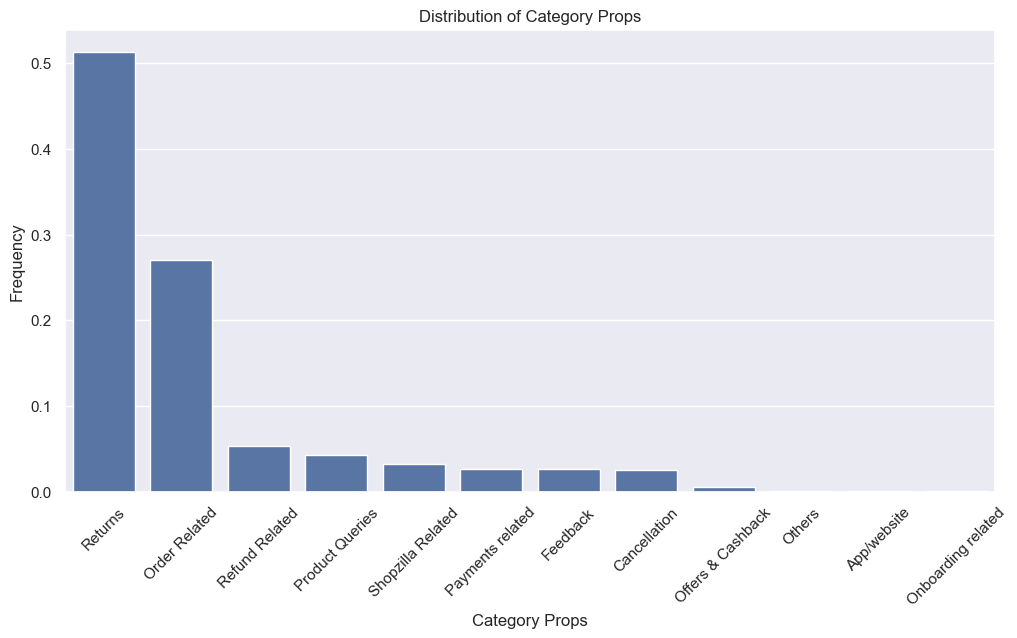

In [123]:
# create the bar chart to visualize the distribution of category_props
plt.figure(figsize=(12,6))
sns.barplot(x=category_props.index, y=category_props.values)
plt.title('Distribution of Category Props')
plt.xlabel('Category Props')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()


In [124]:
# CSAT score distribution across categories

# Crosstab of counts
cat_crosstab = pd.crosstab(data['category'], data['CSAT Score'] , normalize = True)
print(cat_crosstab)

# Mean, Std, Count of CSAT per category
cat_stats = data.groupby('category')['CSAT Score'].agg(['mean','std','count'])
print(cat_stats)


CSAT Score                 1         2         3         4         5
category                                                            
App/website         0.000128  0.000000  0.000000  0.000070  0.000780
Cancellation        0.005064  0.000466  0.000675  0.002992  0.016553
Feedback            0.004086  0.000407  0.000885  0.003131  0.018194
Offers & Cashback   0.000803  0.000023  0.000128  0.000873  0.003760
Onboarding related  0.000105  0.000012  0.000023  0.000058  0.000559
Order Related       0.043419  0.004912  0.009615  0.036633  0.175655
Others              0.000338  0.000047  0.000081  0.000151  0.000535
Payments related    0.002770  0.000407  0.000803  0.003574  0.019533
Product Queries     0.006786  0.001059  0.002084  0.006775  0.026273
Refund Related      0.007194  0.000757  0.001408  0.007089  0.036516
Returns             0.056154  0.006391  0.013200  0.065338  0.372228
Shopzilla Related   0.003876  0.000454  0.000873  0.003911  0.023386
                        mean      

In [125]:
# Checking for the significant relationship between category and CSAT Score

from scipy.stats import chi2_contingency
chi2, p, _, _ = chi2_contingency(cat_crosstab)
print("Chi² p-value:", p)


Chi² p-value: 1.0


Output of Chi Square test of independence 

Since pval < 0.05 therfore rejecting the null hypothesis :
    There is a statistically significant association between category and csat score

In [126]:
from scipy.stats import f_oneway
groups = [grp['CSAT Score'].values for _, grp in data.groupby('category')]
f_stat, p_val = f_oneway(*groups)
print("ANOVA p-value:", p_val)


ANOVA p-value: 2.0102219401078283e-150


Based on the One way anova test ,the mean of the csat score for atleast one of the categories is significantly different from other categories.

In [127]:
data['category'].isnull().sum()
# no missing values

np.int64(0)

No missing values in categories

In [128]:
data['category'].nunique()

12

In [129]:
data['category'].value_counts()

category
Returns               44097
Order Related         23215
Refund Related         4550
Product Queries        3692
Shopzilla Related      2792
Payments related       2327
Feedback               2294
Cancellation           2212
Offers & Cashback       480
Others                   99
App/website              84
Onboarding related       65
Name: count, dtype: int64

There is moderate cardinality (12 distinct values) in the feature.We will combine low frequency category into a new category called 'Others'.The low frequency categories are namely : Offer & Cashback , Others , App/website , Onboarding related.

We will use target encoding for the feature.Target Encoding will replace each unique category with the mean csat score for that category

Frequency encoding for this feature category

In [130]:
freq_map = data['category'].value_counts(normalize=True)
data['category_fe'] = data['category'].map(freq_map)

In [131]:
# combining the four lowest frequency categories into 'Others'
data['category'] = data['category'].replace(['Offers & Cashback', 'Onboarding related', 'App/website'], 'Others')


In [132]:
def regularized_target_encoding(data):
    """Dead simple version for your category column"""
    
    # Step 1: Get averages
    category_averages = data.groupby('category')['CSAT Score'].mean()
    global_average = data['CSAT Score'].mean()
    
    print(f"Global average: {global_average:.2f}")
    
    # Step 2: Apply regularization  
    final_encoding = {}
    
    for category, avg in category_averages.items():
        count = len(data[data['category'] == category])
        
        # Simple rule: if < 1000 samples, pull toward global average
        if count < 1000:
            # Pull 30% toward global average
            regularized = avg * 0.7 + global_average * 0.3
            print(f"{category}: {avg:.2f} → {regularized:.2f} (regularized)")
        else:
            # Keep original average
            regularized = avg
            print(f"{category}: {avg:.2f} → {regularized:.2f} (trusted)")
        
        final_encoding[category] = regularized
    
    # Step 3: Apply to data
    data['category_encoded'] = data['category'].map(final_encoding)
    return data


data = regularized_target_encoding(data)


Global average: 4.24
Cancellation: 3.99 → 3.99 (trusted)
Feedback: 4.16 → 4.16 (trusted)
Order Related: 4.10 → 4.10 (trusted)
Others: 4.13 → 4.16 (regularized)
Payments related: 4.35 → 4.35 (trusted)
Product Queries: 4.04 → 4.04 (trusted)
Refund Related: 4.23 → 4.23 (trusted)
Returns: 4.35 → 4.35 (trusted)
Shopzilla Related: 4.31 → 4.31 (trusted)


Data Analysis and preprocessing of sub category

In [133]:
data['Sub-category'].nunique()
# Total unique sub-categories

57

In [134]:
data['Sub-category'].isna().sum()

np.int64(0)

In [135]:
sub_counts = data['Sub-category'].value_counts()
sub_props  = data['Sub-category'].value_counts(normalize=True)
print("TOP 10 SUB-CATEGORIES BASED ON THEIR COUNT")
print(sub_counts.head(10))
print(sub_props.head(10))


TOP 10 SUB-CATEGORIES BASED ON THEIR COUNT
Sub-category
Reverse Pickup Enquiry          22389
Return request                   8523
Delayed                          7388
Order status enquiry             6922
Installation/demo                4116
Fraudulent User                  4108
Product Specific Information     3589
Refund Enquiry                   2665
Wrong                            2597
Missing                          2556
Name: count, dtype: int64
Sub-category
Reverse Pickup Enquiry          0.260619
Return request                  0.099212
Delayed                         0.086000
Order status enquiry            0.080576
Installation/demo               0.047912
Fraudulent User                 0.047819
Product Specific Information    0.041778
Refund Enquiry                  0.031022
Wrong                           0.030230
Missing                         0.029753
Name: proportion, dtype: float64


RELATIONSHIP WITH CSAT

In [136]:
sub_crosstab = pd.crosstab(data['Sub-category'], data['CSAT Score'] , normalize='columns')
sub_crosstab

CSAT Score,1,2,3,4,5
Sub-category,,,,,
Account updation,0.003028,0.004677,0.001955,0.001159,0.001543
Affiliate Offers,0.003028,0.001559,0.000782,0.002585,0.001946
App/website Related,0.000089,0.000000,0.000000,0.000178,0.000117
Billing Related,0.000178,0.001559,0.000391,0.000535,0.000772
COD Refund Details,0.001425,0.002338,0.001173,0.000891,0.000889
Call back request,0.000980,0.000779,0.002346,0.000802,0.000319
Call disconnected,0.001247,0.002338,0.000391,0.000357,0.000302
Card/EMI,0.000445,0.000779,0.000000,0.000000,0.000218
Commission related,0.000178,0.000000,0.000000,0.000000,0.000017


In [137]:
print('Top 10 sub categories with highest CSAT scores:')
print(sub_crosstab.sort_values(by=5, ascending=False).head(10))
print('Top 10 sub categories with lowest CSAT scores:')
print(sub_crosstab.sort_values(by=1, ascending=False).head(10))

Top 10 sub categories with highest CSAT scores:
CSAT Score                           1         2         3         4         5
Sub-category                                                                  
Reverse Pickup Enquiry        0.284061  0.281372  0.273260  0.259025  0.255514
Return request                0.035619  0.052221  0.061376  0.105268  0.112686
Order status enquiry          0.085307  0.086516  0.082877  0.078171  0.079910
Delayed                       0.118967  0.099766  0.099687  0.094928  0.077226
Fraudulent User               0.021282  0.017927  0.028147  0.044122  0.055001
Installation/demo             0.073286  0.085737  0.080532  0.050183  0.040492
Product Specific Information  0.050045  0.070148  0.066458  0.051074  0.036802
Missing                       0.012378  0.017147  0.018374  0.024155  0.034839
Wrong                         0.017008  0.018706  0.016810  0.025849  0.034369
Refund Enquiry                0.027961  0.029618  0.026192  0.032980  0.031468
Top 

The sub category feature has high cardinality

MEAN , STD AND COUNT FOR TOP 10 SUB CATEGORIES

In [138]:
sub_stats = data.groupby('Sub-category')['CSAT Score'].agg(['mean','std','count']) \
                .sort_values('count', ascending=False)
print(sub_stats.head(10))


                                  mean       std  count
Sub-category                                           
Reverse Pickup Enquiry        4.189468  1.422186  22389
Return request                4.613282  0.940458   8523
Delayed                       4.011505  1.534497   7388
Order status enquiry          4.210344  1.408775   6922
Installation/demo             3.883139  1.590585   4116
Fraudulent User               4.594937  1.004006   4108
Product Specific Information  4.044023  1.472059   3589
Refund Enquiry                4.296811  1.326308   2665
Wrong                         4.533308  1.104754   2597
Missing                       4.613850  0.989152   2556


CHI2 TEST OF INDEPENDENCE

In [139]:
sub_crosstab = pd.crosstab(data['Sub-category'], data['CSAT Score'] )

top_ten_sub_crosstab = sub_crosstab.loc[sub_counts.head(10).index]
top_ten_sub_crosstab

CSAT Score,1,2,3,4,5
Sub-category,,,,,
Reverse Pickup Enquiry,3190,361,699,2906,15233
Return request,400,67,157,1181,6718
Delayed,1336,128,255,1065,4604
Order status enquiry,958,111,212,877,4764
Installation/demo,823,110,206,563,2414
Fraudulent User,239,23,72,495,3279
Product Specific Information,562,90,170,573,2194
Refund Enquiry,314,38,67,370,1876
Wrong,191,24,43,290,2049


In [140]:
chi2, p, _, _ = chi2_contingency(top_ten_sub_crosstab)
print("Chi² p-value:", p)

Chi² p-value: 0.0


This suggests very strong statistically significant association between sub-category and csat score

In [141]:
from scipy.stats import f_oneway

# Get the names of the top 10 sub-categories by count
top_10_subs = sub_counts.head(10).index

# Create a list of CSAT Score arrays for each top sub-category
sub_groups = [data[data['Sub-category'] == sub]['CSAT Score'] for sub in top_10_subs]

# Perform one-way ANOVA
f_stat, p_val = f_oneway(*sub_groups)
print("ANOVA p-value for top 10 sub-categories:", p_val)

ANOVA p-value for top 10 sub-categories: 0.0


Atleast one subcategory has a significantly different mean csat score

frequency encoding the sub category column

In [142]:
# Frequency encoding for sub-category
freq_map = data['Sub-category'].value_counts(normalize=True)
data['subcat_fe'] = data['Sub-category'].map(freq_map)


For sub categories , we could have gone for less frequency sub-categories combined into a single "Others" sub-category.Like if sub category frequency less than 300 , we could have combined them into "Others".This way we reduce the number of sub categories and the also the better estimate of the mean


In [143]:
# low_subcat
c = np.where((data['Sub-category'].value_counts() < 300) == True)[0]
low_subcat = data['Sub-category'].value_counts().index[c]
low_subcat

Index(['Return cancellation', 'Wallet related', 'Other Cashback',
       'Product related Issues', 'Affiliate Offers', 'Unable to track',
       'Account updation', 'PayLater related', 'COD Refund Details',
       'Shopzilla Rewards', 'Instant discount', 'Warranty related',
       'Issues with Shopzilla App', 'Order Verification', 'Seller onboarding',
       'Service Center - Service Denial', 'Billing Related', 'Self-Help',
       'Call back request', 'e-Gift Voucher', 'Call disconnected',
       'Life Insurance', 'Other Account Related Issues', 'Card/EMI',
       'Payment pending', 'Others', 'App/website Related', 'Unable to Login',
       'Commission related', 'Policy Related', 'Non Order related'],
      dtype='object', name='Sub-category')

In [144]:
len(low_subcat)

31

In [145]:
# Replace low frequency sub-categories with "Others"
data['Sub-category'] = data['Sub-category'].replace(low_subcat, 'Others')
print("Sub-category feature has high cardinality, consider combining low-frequency categories into 'Others'.")

Sub-category feature has high cardinality, consider combining low-frequency categories into 'Others'.


In [146]:
data['Sub-category'].nunique()

27

Target Encoding the sub category column

In [147]:
# K-fold target encoding to avoid leakage
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)
data['subcat_te'] = np.nan

for train_idx, val_idx in kf.split(data):
    train, val = data.iloc[train_idx], data.iloc[val_idx]
    means = train.groupby('Sub-category')['CSAT Score'].mean()
    data.loc[val_idx, 'subcat_te'] = val['Sub-category'].map(means)

# For any unseen or all-null groups, fill with global mean
global_mean = data['CSAT Score'].mean()
data['subcat_te'].fillna(global_mean, inplace=True)


In [148]:
data.columns

Index(['channel_name', 'category', 'Sub-category', 'Customer Remarks',
       'order_date_time', 'Issue_reported at', 'issue_responded',
       'Survey_response_Date', 'Customer_City', 'Product_category',
       'Item_price', 'connected_handling_time', 'Agent_name', 'Supervisor',
       'Manager', 'Tenure Bucket', 'Agent Shift', 'CSAT Score',
       'channel_Inbound', 'channel_Outcall', 'category_fe', 'category_encoded',
       'subcat_fe', 'subcat_te'],
      dtype='object')

Data analysis and preprocessing of Customer Remarks column

In [149]:
data['Customer Remarks']

0                                             NaN
1                                             NaN
2                                             NaN
3                                             NaN
4                                             NaN
                           ...                   
85902                                         NaN
85903    Supported team customer executive   good
85904        need to improve with proper details.
85905                                         NaN
85906                                         NaN
Name: Customer Remarks, Length: 85907, dtype: object

In [150]:
# filling the null remarks with a placeholder 

data['Customer Remarks'].fillna("<Missing_Remark>" , inplace = True)

Character and Word length distribution

Character Length Distribution:
count    85907.000000
mean        25.162688
std         46.572114
min          1.000000
25%         16.000000
50%         16.000000
75%         16.000000
max       2673.000000
Name: remark_char_length, dtype: float64
Word Count Distribution:
count    85907.000000
mean         3.187889
std          8.444472
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max        444.000000
Name: remark_word_count, dtype: float64


Text(0.5, 1.0, 'Word Count by CSAT Score')

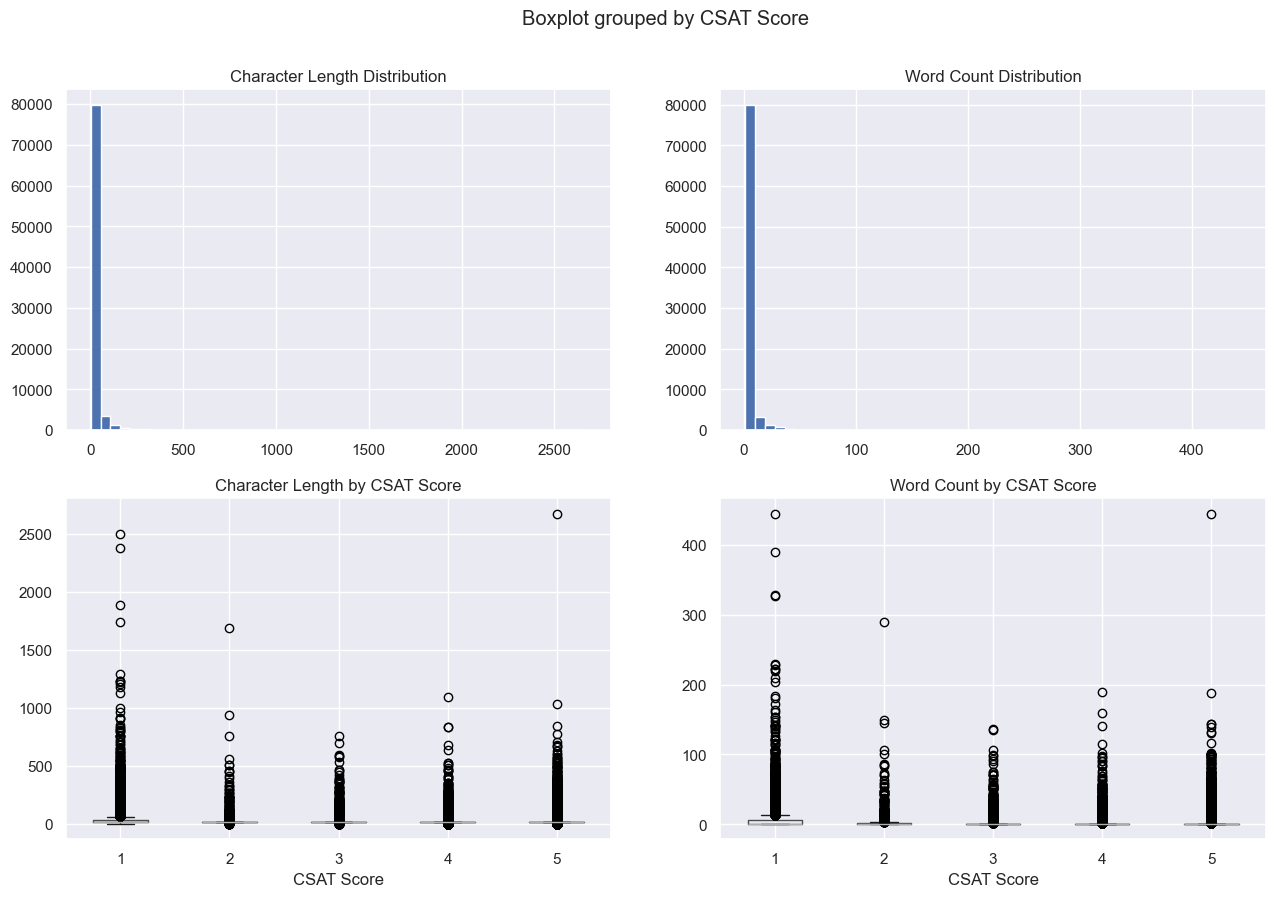

In [151]:
# Basic text statistics
data['remark_char_length'] = data['Customer Remarks'].str.len()
data['remark_word_count'] = data['Customer Remarks'].str.split().str.len()
data['remark_sentence_count'] = data['Customer Remarks'].str.split('.').str.len()

# Distribution analysis
print("Character Length Distribution:")
print(data['remark_char_length'].describe())

print("Word Count Distribution:")
print(data['remark_word_count'].describe())

# Visualizations
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Character length distribution
data['remark_char_length'].hist(bins=50, ax=axes[0,0])
axes[0,0].set_title('Character Length Distribution')

# Word count distribution  
data['remark_word_count'].hist(bins=50, ax=axes[0,1])
axes[0,1].set_title('Word Count Distribution')

# Box plots by CSAT Score
data.boxplot(column='remark_char_length', by='CSAT Score', ax=axes[1,0])
axes[1,0].set_title('Character Length by CSAT Score')

data.boxplot(column='remark_word_count', by='CSAT Score', ax=axes[1,1])
axes[1,1].set_title('Word Count by CSAT Score')


Missing Remark Analysis

In [152]:
# Analyze missing remarks pattern
missing_remarks_count = data[data['Customer Remarks'] == '<Missing_Remark>'].shape[0]
missing_percentage = (missing_remarks_count / len(data)) * 100

print(f"Missing Remarks: {missing_remarks_count} ({missing_percentage:.2f}%)")

# CSAT distribution for missing vs non-missing remarks
missing_csat = data[data['Customer Remarks'] == '<Missing_Remark>']['CSAT Score'].value_counts()
non_missing_csat = data[data['Customer Remarks'] != '<Missing_Remark>']['CSAT Score'].value_counts()

print("CSAT Distribution - Missing Remarks:")
print(missing_csat)
print("CSAT Distribution - Non-Missing Remarks:")
print(non_missing_csat)


Missing Remarks: 57165 (66.54%)
CSAT Distribution - Missing Remarks:
CSAT Score
5    39950
4     8616
1     5882
3     1828
2      889
Name: count, dtype: int64
CSAT Distribution - Non-Missing Remarks:
CSAT Score
5    19667
1     5348
4     2603
3      730
2      394
Name: count, dtype: int64


In [153]:
print("Percentages of each csat score category for records where remarks are missing:")
print((missing_csat/missing_remarks_count)*100)
print("Percentages of each csat score category for records where remarks are not missing:")
non_missing_remarks_count = len(data) - missing_remarks_count
print((non_missing_csat/non_missing_remarks_count)*100)

Percentages of each csat score category for records where remarks are missing:
CSAT Score
5    69.885419
4    15.072160
1    10.289513
3     3.197761
2     1.555147
Name: count, dtype: float64
Percentages of each csat score category for records where remarks are not missing:
CSAT Score
5    68.425997
1    18.606917
4     9.056433
3     2.539837
2     1.370816
Name: count, dtype: float64


This distribution of percentage for missing and non missing remark records shows that presence or absence of remark have similar distributions across different CSAT score categories.Therefore the presence or absence of remark could not help in predicting CSAT scores.

In [154]:
# checking the mean remark word count for each csat score category
missing_data = data[data['remark_word_count'].isnull()]
non_missing_data = data[data['remark_word_count'].notnull()]
all_data_mean_word_count = data.groupby('CSAT Score')['remark_word_count'].mean()

print("Mean word count for all data:")
print(all_data_mean_word_count)



Mean word count for all data:
CSAT Score
1    6.819590
2    4.784879
3    3.904613
4    2.498797
5    2.568345
Name: remark_word_count, dtype: float64


However , the presence of customer remarks has provided a very important insight in the customer behaviour : 

For those records , where there is presence of remarks , the customer remarks tends to be longer for low CSAT score records compared to those with higher CSAT scores.

BASIC SENTIMENT AND CSAT CORRELATION ANALYSIS

In [155]:
from textblob import TextBlob
import pandas as pd

# Basic sentiment analysis (excluding missing remarks)
non_missing_data = data[data['Customer Remarks'] != '<Missing_Remark>'].copy()

def get_sentiment_scores(text):
    blob = TextBlob(text)
    return blob.sentiment.polarity, blob.sentiment.subjectivity

# Apply sentiment analysis
sentiment_scores = non_missing_data['Customer Remarks'].apply(get_sentiment_scores)
non_missing_data['sentiment_polarity'] = [score[0] for score in sentiment_scores]
non_missing_data['sentiment_subjectivity'] = [score[1] for score in sentiment_scores]

# Correlation with CSAT
sentiment_csat_corr = non_missing_data[['sentiment_polarity', 'sentiment_subjectivity', 'CSAT Score']].corr()
print("Sentiment-CSAT Correlation:")
print(sentiment_csat_corr)

# Sentiment distribution by CSAT Score
sentiment_by_csat = non_missing_data.groupby('CSAT Score')[['sentiment_polarity', 'sentiment_subjectivity']].mean()
print("Average Sentiment by CSAT Score:")
print(sentiment_by_csat)


Sentiment-CSAT Correlation:
                        sentiment_polarity  sentiment_subjectivity  CSAT Score
sentiment_polarity                1.000000                0.422366    0.522431
sentiment_subjectivity            0.422366                1.000000    0.120746
CSAT Score                        0.522431                0.120746    1.000000
Average Sentiment by CSAT Score:
            sentiment_polarity  sentiment_subjectivity
CSAT Score                                            
1                    -0.169262                0.384283
2                     0.023047                0.349440
3                     0.118096                0.357286
4                     0.297927                0.412265
5                     0.425706                0.487173


CSAT Score shows high correlation with the sentiment_polarity feature (0.522)

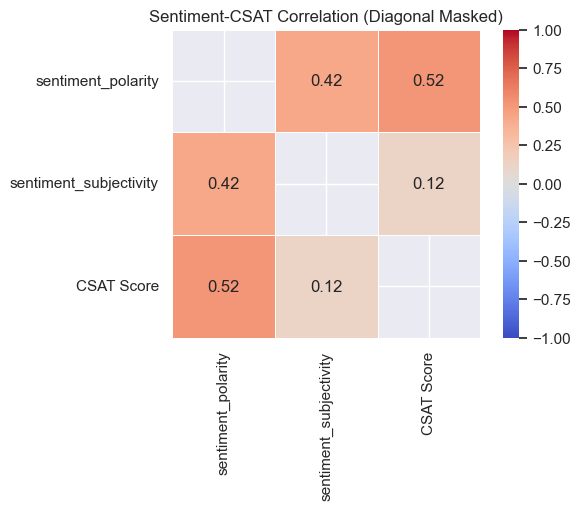

In [156]:
# correlation heat map for sentiment_csat_corr


sentiment_csat_corr_copy = sentiment_csat_corr.copy()

# sentiment_csat_corr is your correlation matrix
mask = np.eye(sentiment_csat_corr_copy.shape[0], dtype=bool)  # Mask for diagonal

plt.figure(figsize=(6, 4))
sns.heatmap(
    sentiment_csat_corr_copy,
    annot=True,
    cmap='coolwarm',
    center=0,
    mask=mask,
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True,
    cbar=True
)
plt.title("Sentiment-CSAT Correlation (Diagonal Masked)")
plt.show()

There is significant correlation between sentiment polarity and csat score (= 0.522)

With the increase in csat score , we can see significant change in sentiment polarity scores.Sentiment subjectivity score also tends to increase slighly with increase in csat score.

However we have to keep in mind that textblob model is not deep learning sentiment analysis model . It is rather a lexicon based model where each word has predefined polarity and subjectivity scores . Its scores may not do well on contextual understanding of the text like inefficient understanding of sarcasm or ambiguous text.

Unigram , Bigram and N-gram analysis for pattern discovery : Identifying common phrases and patterns

In [157]:
from sklearn.feature_extraction.text import CountVectorizer
import re

# Clean text for n-gram analysis (excluding missing remarks)
def basic_clean_for_ngram(text):
    if text == '<Missing_Remark>':
        return text
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

non_missing_data['cleaned_remarks'] = non_missing_data['Customer Remarks'].apply(basic_clean_for_ngram)

# Unigram analysis
unigram_vectorizer = CountVectorizer(ngram_range=(1,1), stop_words='english', max_features=50)
unigram_matrix = unigram_vectorizer.fit_transform(non_missing_data['cleaned_remarks'])
unigram_freq = dict(zip(unigram_vectorizer.get_feature_names_out(), 
                       unigram_matrix.sum(axis=0).A1))
print("Top 20 Unigrams:")
for word, freq in sorted(unigram_freq.items(), key=lambda x: x[1], reverse=True)[:20]:
    print(f"{word}: {freq}")

# Bigram analysis  
bigram_vectorizer = CountVectorizer(ngram_range=(2,2), stop_words='english', max_features=30)
bigram_matrix = bigram_vectorizer.fit_transform(non_missing_data['cleaned_remarks'])
bigram_freq = dict(zip(bigram_vectorizer.get_feature_names_out(), 
                      bigram_matrix.sum(axis=0).A1))
print("\nTop 15 Bigrams:")
for bigram, freq in sorted(bigram_freq.items(), key=lambda x: x[1], reverse=True)[:15]:
    print(f"{bigram}: {freq}")

# N-gram analysis by CSAT score
for csat_score in sorted(non_missing_data['CSAT Score'].unique()):
    csat_remarks = non_missing_data[non_missing_data['CSAT Score'] == csat_score]['cleaned_remarks']
    if len(csat_remarks) > 0:
        vectorizer = CountVectorizer(ngram_range=(1,2), stop_words='english', max_features=10)
        matrix = vectorizer.fit_transform(csat_remarks)
        freq = dict(zip(vectorizer.get_feature_names_out(), matrix.sum(axis=0).A1))
        print(f"\nTop phrases for CSAT Score {csat_score}:")
        for phrase, f in sorted(freq.items(), key=lambda x: x[1], reverse=True)[:5]:
            print(f"  {phrase}: {f}")


Top 20 Unigrams:
good: 8191
customer: 3723
shopzilla: 2801
service: 2458
product: 1937
nice: 1901
support: 1619
thank: 1492
delivery: 1452
issue: 1448
thanks: 1389
problem: 1369
executive: 1299
time: 1275
care: 1219
order: 1021
return: 904
happy: 862
bad: 812
solve: 698

Top 15 Bigrams:
customer care: 958
customer support: 748
customer service: 625
good service: 390
customer executive: 237
issue resolved: 222
support executive: 205
good customer: 204
solve problem: 203
care executive: 200
resolve issue: 196
good job: 178
thanks shopzilla: 174
shopzilla customer: 173
thank shopzilla: 173

Top phrases for CSAT Score 1:
  shopzilla: 1101
  customer: 1040
  service: 915
  product: 790
  bad: 621

Top phrases for CSAT Score 2:
  shopzilla: 67
  customer: 64
  product: 60
  good: 45
  delivery: 43

Top phrases for CSAT Score 3:
  good: 114
  customer: 106
  product: 102
  shopzilla: 98
  delivery: 89

Top phrases for CSAT Score 4:
  good: 769
  customer: 286
  product: 223
  shopzilla: 193
 

Top 10 Trigrams  and tri gram analysis by csat score

In [158]:
# non_missing_data['cleaned_remarks']

# Trigram analysis
trigram_vectorizer = CountVectorizer(ngram_range=(3,3), stop_words='english', max_features=20)
trigram_matrix = trigram_vectorizer.fit_transform(non_missing_data['cleaned_remarks'])
trigram_freq = dict(zip(trigram_vectorizer.get_feature_names_out(), 
                       trigram_matrix.sum(axis=0).A1))
print("Top 10 Trigrams:")
for trigram, freq in sorted(trigram_freq.items(), key=lambda x: x[1], reverse=True)[:10]:
    print(f"{trigram}: {freq}")
# tri-gram analysis by CSAT score
for csat_score in sorted(non_missing_data['CSAT Score'].unique()):
    csat_remarks = non_missing_data[non_missing_data['CSAT Score'] == csat_score]['cleaned_remarks']
    if len(csat_remarks) > 0:
        vectorizer = CountVectorizer(ngram_range=(3,3), stop_words='english', max_features=10)
        matrix = vectorizer.fit_transform(csat_remarks)
        freq = dict(zip(vectorizer.get_feature_names_out(), matrix.sum(axis=0).A1))
        print(f"\nTop phrases for CSAT Score {csat_score}:")
        for phrase, f in sorted(freq.items(), key=lambda x: x[1], reverse=True)[:5]:
            print(f"  {phrase}: {f}")


Top 10 Trigrams:
customer care executive: 178
customer support executive: 152
customer care service: 94
shopzilla customer care: 76
good customer support: 67
good customer service: 64
customer service good: 62
open box delivery: 54
customer care support: 50
customer service executive: 47

Top phrases for CSAT Score 1:
  customer care executive: 43
  worst customer service: 24
  customer support executive: 23
  bad experience shopzilla: 20
  worst service shopzilla: 18

Top phrases for CSAT Score 2:
  want return product: 4
  customer care executive: 3
  shown opd facility: 3
  open box delivery: 2
  pay later account: 2

Top phrases for CSAT Score 3:
  customer care executive: 4
  open box delivery: 4
  money deducted order: 2
  need lodge complaint: 2
  non returnable products: 2

Top phrases for CSAT Score 4:
  customer care executive: 10
  customer support executive: 10
  problem soon possible: 7
  customer support good: 6
  customer care number: 5

Top phrases for CSAT Score 5:
  c

Identifying Key themes in customer remarks using Topic Modelling 

In [159]:
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import TfidfVectorizer

# Advanced text preprocessing for topic modeling
def preprocess_for_topics(text):
    if text == '<Missing_Remark>':
        return ""
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Remove very short texts
    if len(text.split()) < 3:
        return ""
    return text

topic_data = non_missing_data['Customer Remarks'].apply(preprocess_for_topics)
topic_data = topic_data[topic_data != ""]  # Remove empty strings

# TF-IDF vectorization
tfidf_vectorizer = TfidfVectorizer(max_features=50, stop_words='english',
                                  ngram_range=(1,2), min_df=5, max_df=0.7)
tfidf_matrix = tfidf_vectorizer.fit_transform(topic_data)

# LDA topic modeling
n_topics = 3
lda = LatentDirichletAllocation(n_components=n_topics, random_state=42, max_iter=100)
lda.fit(tfidf_matrix)

# Display top words per topic
feature_names = tfidf_vectorizer.get_feature_names_out()
for topic_idx, topic in enumerate(lda.components_):
    top_words = [feature_names[i] for i in topic.argsort()[-10:]]
    print(f"Topic {topic_idx + 1}: {', '.join(reversed(top_words))}")


Topic 1: customer, delivery, problem, executive, time, care, happy, customer care, solve, resolve
Topic 2: shopzilla, issue, service, thank, nice, order, resolved, make, talk, products
Topic 3: good, product, support, thanks, return, bad, customer support, customer, experience, person


In [160]:
data[['Customer Remarks','remark_char_length','remark_word_count','remark_sentence_count']]

,Customer Remarks,remark_char_length,remark_word_count,remark_sentence_count
0,<Missing_Remark>,16,1,1
1,<Missing_Remark>,16,1,1
2,<Missing_Remark>,16,1,1
3,<Missing_Remark>,16,1,1
4,<Missing_Remark>,16,1,1
...,...,...,...,...
85902,<Missing_Remark>,16,1,1
85903,Supported team customer executive good,40,5,1
85904,need to improve with proper details.,36,6,2
85905,<Missing_Remark>,16,1,1


Preprocessing of Customer Remarks

In [161]:
import re
import nltk
from nltk.corpus import stopwords  
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import string

# Download required NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')

class CustomerRemarksPreprocessor:
    def __init__(self):
        self.stop_words = set(stopwords.words('english'))
        self.lemmatizer = WordNetLemmatizer()
        
    def clean_text(self, text):
        """Comprehensive text cleaning"""
        # Handle missing remarks token
        if text == '<Missing_Remark>':
            return text
            
        # Convert to lowercase
        text = text.lower()
        
        # Remove HTML tags if any
        text = re.sub(r'<[^>]+>', '', text)
        
        # Remove URLs
        text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
        
        # Remove email addresses
        text = re.sub(r'\S+@\S+', '', text)
        
        # Remove extra whitespace and newlines
        text = re.sub(r'\s+', ' ', text)
        
        # Remove punctuation except important ones for sentiment
        # Keep some punctuation that might be important for sentiment
        text = re.sub(r'[^\w\s!?.]', ' ', text)
        
        return text.strip()
    
    def tokenize_and_lemmatize(self, text):
        """Tokenization and lemmatization"""
        if text == '<Missing_Remark>':
            return [text]
            
        # Tokenize
        tokens = word_tokenize(text)
        
        # Remove stopwords and lemmatize
        tokens = [self.lemmatizer.lemmatize(token) for token in tokens 
                 if token not in self.stop_words and len(token) > 2]
        
        # Filter out tokens that are just punctuation
        tokens = [token for token in tokens if not all(c in string.punctuation for c in token)]
        
        return tokens
    
    def preprocess(self, text):
        """Complete preprocessing pipeline"""
        cleaned_text = self.clean_text(text)
        tokens = self.tokenize_and_lemmatize(cleaned_text)
        return ' '.join(tokens)

# Apply preprocessing
preprocessor = CustomerRemarksPreprocessor()
data['cleaned_remarks'] = data['Customer Remarks'].apply(preprocessor.preprocess)

print("Preprocessing completed for remarks")
print(data[['Customer Remarks', 'cleaned_remarks']].head())


[nltk_data] Downloading package punkt to C:\Users\Ankur
[nltk_data]     Bhatt\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\Ankur
[nltk_data]     Bhatt\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Ankur
[nltk_data]     Bhatt\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\Ankur Bhatt\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


Preprocessing completed for remarks
   Customer Remarks   cleaned_remarks
0  <Missing_Remark>  <Missing_Remark>
1  <Missing_Remark>  <Missing_Remark>
2  <Missing_Remark>  <Missing_Remark>
3  <Missing_Remark>  <Missing_Remark>
4  <Missing_Remark>  <Missing_Remark>


In [162]:
data[['Customer Remarks', 'cleaned_remarks']].sample(10)

,Customer Remarks,cleaned_remarks
79820,<Missing_Remark>,<Missing_Remark>
47388,<Missing_Remark>,<Missing_Remark>
24121,Delivery partner response not proper,delivery partner response proper
31119,Very good,good
10937,Best customer service support,best customer service support
54590,very good,good
36199,<Missing_Remark>,<Missing_Remark>
6569,<Missing_Remark>,<Missing_Remark>
64165,<Missing_Remark>,<Missing_Remark>
76951,<Missing_Remark>,<Missing_Remark>


In [163]:
# creating has_missing_remarks column
data['has_missing_remarks'] = data['cleaned_remarks'].apply(lambda x: 1 if x == '<Missing_Remark>' else 0)

In [164]:
# Replacing the remark_char_length , remark_word_count , remark_sentence_count for records having cleaned_remarks value as <Missing_Remark> with -1
data.loc[data['cleaned_remarks'] == '<Missing_Remark>', 'remark_char_length'] = -1
data.loc[data['cleaned_remarks'] == '<Missing_Remark>', 'remark_word_count'] = -1
data.loc[data['cleaned_remarks'] == '<Missing_Remark>', 'remark_sentence_count'] = -1


Sequence preparation for the LSTM text branch

In [165]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

class SequencePreprocessor:
    def __init__(self, max_words=10000, max_len=100):
        self.max_words = max_words
        self.max_len = max_len
        self.tokenizer = None
        
    def fit_tokenizer(self, texts):
        """Fit tokenizer on text data"""
        self.tokenizer = Tokenizer(num_words=self.max_words, oov_token='<OOV>')
        self.tokenizer.fit_on_texts(texts)
        print(f"Vocabulary size: {len(self.tokenizer.word_index)}")
        
    def texts_to_sequences(self, texts):
        """Convert texts to sequences"""
        sequences = self.tokenizer.texts_to_sequences(texts)
        padded_sequences = pad_sequences(sequences, maxlen=self.max_len, padding='post')
        return padded_sequences
    
    def get_vocab_size(self):
        """Get actual vocabulary size for embedding layer"""
        return min(len(self.tokenizer.word_index) + 1, self.max_words)

# Analyze sequence lengths to determine max_len
sequence_lengths = data['cleaned_remarks'].apply(lambda x: len(x.split()))
print("Sequence length statistics:")
print(sequence_lengths.describe())
print(f"95th percentile: {sequence_lengths.quantile(0.95)}")
print(f"99th percentile: {sequence_lengths.quantile(0.99)}")

# Choose max_len based on analysis (e.g., 95th percentile)
MAX_LEN = int(sequence_lengths.quantile(0.95))
print(f"Selected MAX_LEN: {MAX_LEN}")




Sequence length statistics:
count    85907.000000
mean         2.129012
std          4.366201
min          0.000000
25%          1.000000
50%          1.000000
75%          1.000000
max        263.000000
Name: cleaned_remarks, dtype: float64
95th percentile: 8.0
99th percentile: 19.0
Selected MAX_LEN: 8


In [166]:
# Initialize and fit sequence preprocessor
seq_processor = SequencePreprocessor(max_words=10000, max_len=MAX_LEN)
seq_processor.fit_tokenizer(data['cleaned_remarks'])

# Convert to sequences
X_text_sequences = seq_processor.texts_to_sequences(data['cleaned_remarks'])
print(f"Text sequences shape: {X_text_sequences.shape}")

# Save preprocessor for later use
import pickle
with open('text_preprocessor.pkl', 'wb') as f:
    pickle.dump(seq_processor, f)

Vocabulary size: 9241
Text sequences shape: (85907, 8)


Creating Context Retaining embeddings using LSTM for CustomerRemarks

In [167]:
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout
from tensorflow.keras.models import Model

# Text branch architecture
def create_text_branch(vocab_size, embedding_dim=100, lstm_units=64, max_len=MAX_LEN):
    """
    Customer_Remarks -> Embedding -> LSTM -> Dense(64)
    """
    # Text input
    text_input = Input(shape=(max_len,), name='text_input')
    
    # Embedding layer
    # You can use pre-trained embeddings here if needed
    text_embed = Embedding(input_dim=vocab_size, 
                          output_dim=embedding_dim,
                          input_length=max_len,
                          name='text_embedding')(text_input)
    
    # LSTM layer
    text_lstm = LSTM(lstm_units, dropout=0.2, recurrent_dropout=0.2,
                    name='text_lstm')(text_embed)
    
    # Dense layer
    text_dense = Dense(64, activation='relu', name='text_dense')(text_lstm)
    text_dropout = Dropout(0.3)(text_dense)
    
    return text_input, text_dropout

# Create the text branch
vocab_size = seq_processor.get_vocab_size()
text_input, text_features = create_text_branch(vocab_size)

print(f"Text branch created with vocab_size: {vocab_size}")
print(f"Text features output shape: (batch_size, 64)")


Text branch created with vocab_size: 9242
Text features output shape: (batch_size, 64)


In [168]:
# Wrap the text branch into a model
text_encoder = Model(inputs=text_input, outputs=text_features)

# Generate embeddings for customer remarks
X_embeddings = text_encoder.predict(X_text_sequences, batch_size=32)
print(X_embeddings.shape)  # (85907, 64)


2685/2685 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
(85907, 64)


Using non_missing_data df for providing the sentiment polarity and sentiment subjectivity scores for each text.

In [169]:
non_missing_data.shape

(28742, 30)

In [170]:
non_missing_data.index

Index([    7,     8,    11,    17,    19,    21,    23,    25,    27,    29,
       ...
       85874, 85876, 85879, 85881, 85882, 85887, 85888, 85896, 85903, 85904],
      dtype='int64', length=28742)

In [171]:
non_missing_data[['sentiment_polarity', 'sentiment_subjectivity']].head()

,sentiment_polarity,sentiment_subjectivity
7,0.91,0.780000
8,0.91,0.780000
11,-0.91,0.866667
17,0.00,0.000000
19,0.70,0.600000


In [172]:
data['sentiment_polarity'] = non_missing_data['sentiment_polarity']
data['sentiment_subjectivity'] = non_missing_data['sentiment_subjectivity']
# fill the na values with 0
data['sentiment_polarity'].fillna(0, inplace=True)
data['sentiment_subjectivity'].fillna(0, inplace=True)


data.head()

,channel_name,category,Sub-category,Customer Remarks,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score,channel_Inbound,channel_Outcall,category_fe,category_encoded,subcat_fe,subcat_te,remark_char_length,remark_word_count,remark_sentence_count,cleaned_remarks,has_missing_remarks,sentiment_polarity,sentiment_subjectivity
0,Outcall,Product Queries,Others,<Missing_Remark>,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5,False,True,0.042977,4.039816,0.000268,4.185167,-1,-1,-1,<Missing_Remark>,1,0.0,0.0
1,Outcall,Product Queries,Product Specific Information,<Missing_Remark>,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5,False,True,0.042977,4.039816,0.041778,4.013627,-1,-1,-1,<Missing_Remark>,1,0.0,0.0
2,Inbound,Order Related,Installation/demo,<Missing_Remark>,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5,True,False,0.270234,4.096059,0.047912,3.865802,-1,-1,-1,<Missing_Remark>,1,0.0,0.0
3,Inbound,Returns,Reverse Pickup Enquiry,<Missing_Remark>,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5,True,False,0.513311,4.346350,0.260619,4.191937,-1,-1,-1,<Missing_Remark>,1,0.0,0.0
4,Inbound,Cancellation,Not Needed,<Missing_Remark>,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5,True,False,0.025749,3.990506,0.022350,3.921189,-1,-1,-1,<Missing_Remark>,1,0.0,0.0


order_date_time feature analysis and preprocessing

In [173]:
# data['order_date_time']
# data[~data['order_date_time'].isna()]
# order_date_time feature analysis and preprocessing
data['order_date_time'].isna().sum()

np.int64(68693)

Missing Data Pattern Analysis

In [174]:
# Analyze missing data patterns
missing_analysis = {
    'total_records': len(data),
    'missing_count': data['order_date_time'].isna().sum(),
    'missing_percentage': (data['order_date_time'].isna().sum() / len(data)) * 100,
    'available_count': data['order_date_time'].notna().sum()
}

print("Missing Data Analysis:")
for key, value in missing_analysis.items():
    print(f"{key}: {value}")



Missing Data Analysis:
total_records: 85907
missing_count: 68693
missing_percentage: 79.96205198645046
available_count: 17214


In [175]:
# Check if missingness correlates with CSAT scores
missing_csat_analysis = data.groupby(data['order_date_time'].isna())['CSAT Score'].agg(['mean', 'count', 'std'])
print("\nCSAT Distribution by Missing Order Date:")
print(missing_csat_analysis)





CSAT Distribution by Missing Order Date:
                     mean  count       std
order_date_time                           
False            3.966597  17214  1.580281
True             4.311211  68693  1.314640


In [176]:
# Check correlation with other features
correlation_with_missing = {}
categorical_features = ['channel_name', 'category', 'Sub-category']
for feature in categorical_features:
    contingency = pd.crosstab(data[feature], data['order_date_time'].isna())
    print(f"\n{feature} vs Missing Order Date:")
    print(contingency)


channel_name vs Missing Order Date:
order_date_time  False  True 
channel_name                 
Email             1149   1874
Inbound          13890  54252
Outcall           2175  12567

category vs Missing Order Date:
order_date_time    False  True 
category                       
Cancellation         802   1410
Feedback             538   1756
Order Related       6284  16931
Others                90    638
Payments related      49   2278
Product Queries       17   3675
Refund Related      1172   3378
Returns             8242  35855
Shopzilla Related     20   2772

Sub-category vs Missing Order Date:
order_date_time                   False  True 
Sub-category                                  
Customer Requested Modifications    104    701
Damaged                              87    388
Delayed                            3675   3713
Exchange / Replacement              187    709
Fraudulent User                     798   3310
General Enquiry                      50   1895
Installation/de

Available DateTime Data Analysis

In [177]:
data['order_date_time'].sample(10)

13615    NaN
32798    NaN
41840    NaN
65964    NaN
63532    NaN
40701    NaN
30884    NaN
2499     NaN
48096    NaN
34931    NaN
Name: order_date_time, dtype: object

In [178]:
# Extract non-null datetime data
available_datetime = data[data['order_date_time'].notna()].copy()

if len(available_datetime) > 0:
    # Convert to proper datetime format if needed
    available_datetime['order_date_time'] = pd.to_datetime(available_datetime['order_date_time'], 
                                                          format='%d/%m/%Y %H:%M')
    
    # Basic temporal statistics
    print("Temporal Range Analysis:")
    print(f"Earliest order: {available_datetime['order_date_time'].min()}")
    print(f"Latest order: {available_datetime['order_date_time'].max()}")
    print(f"Date range span: {(available_datetime['order_date_time'].max() - available_datetime['order_date_time'].min()).days} days")
    
    # Extract temporal components for analysis
    available_datetime['year'] = available_datetime['order_date_time'].dt.year
    available_datetime['month'] = available_datetime['order_date_time'].dt.month
    available_datetime['day'] = available_datetime['order_date_time'].dt.day
    available_datetime['hour'] = available_datetime['order_date_time'].dt.hour
    available_datetime['minute'] = available_datetime['order_date_time'].dt.minute
    available_datetime['day_of_week'] = available_datetime['order_date_time'].dt.dayofweek
    available_datetime['is_weekend'] = available_datetime['day_of_week'].isin([5, 6]).astype(int)
    
    # Temporal distribution analysis
    print("\nTemporal Component Analysis:")
    print("Year distribution:", available_datetime['year'].value_counts().sort_index())
    print("Month distribution:", available_datetime['month'].value_counts().sort_index())
    print("Hour distribution:", available_datetime['hour'].value_counts().sort_index())
    print("Day of week distribution:", available_datetime['day_of_week'].value_counts().sort_index())
    print("Weekend vs Weekday:", available_datetime['is_weekend'].value_counts())


Temporal Range Analysis:
Earliest order: 2022-01-16 13:15:00
Latest order: 2023-12-08 23:36:00
Date range span: 691 days

Temporal Component Analysis:
Year distribution: year
2022      203
2023    17011
Name: count, dtype: int64
Month distribution: month
1        41
2        46
3        68
4        82
5       143
6       321
7      4965
8     11331
9        83
10       57
11       32
12       45
Name: count, dtype: int64
Hour distribution: hour
0      588
1      314
2      147
3       97
4       57
5      106
6      248
7      470
8      661
9      751
10     899
11    1019
12    1069
13     973
14     882
15     941
16     921
17     930
18     956
19     999
20    1070
21    1155
22    1097
23     864
Name: count, dtype: int64
Day of week distribution: day_of_week
0    2258
1    2489
2    2281
3    2348
4    2736
5    2589
6    2513
Name: count, dtype: int64
Weekend vs Weekday: is_weekend
0    12112
1     5102
Name: count, dtype: int64


Temporal-CSAT Relationship Analysis

Identify temporal patterns that correlate with customer satisfaction:

In [179]:
# CSAT analysis by temporal features
temporal_csat_analysis = {}

temporal_features = ['month', 'hour', 'day_of_week', 'is_weekend']
for feature in temporal_features:
    if feature in available_datetime.columns:
        feature_csat = available_datetime.groupby(feature)['CSAT Score'].agg(['mean', 'std', 'count'])
        temporal_csat_analysis[feature] = feature_csat
        print(f"\nCSAT Analysis by {feature}:")
        print(feature_csat)

# Time-of-day analysis
available_datetime['time_period'] = pd.cut(available_datetime['hour'], 
                                         bins=[0, 6, 12, 18, 24], 
                                         labels=['Night', 'Morning', 'Afternoon', 'Evening'],
                                         include_lowest=True)

time_period_csat = available_datetime.groupby('time_period')['CSAT Score'].agg(['mean', 'std', 'count'])
print("\nCSAT Analysis by Time Period:")
print(time_period_csat)

# Statistical testing for temporal patterns
from scipy.stats import f_oneway, chi2_contingency

# ANOVA test for mean CSAT differences across hours
hour_groups = [group['CSAT Score'].values for name, group in available_datetime.groupby('hour')]
if len(hour_groups) > 1:
    f_stat, p_value = f_oneway(*hour_groups)
    print(f"\nANOVA test for CSAT differences across hours: F={f_stat:.3f}, p={p_value:.3f}")




CSAT Analysis by month:
           mean       std  count
month                           
1      3.731707  1.761028     41
2      3.782609  1.787774     46
3      3.676471  1.740142     68
4      3.402439  1.897755     82
5      3.706294  1.743528    143
6      3.570093  1.761279    321
7      3.765760  1.690411   4965
8      4.079516  1.501848  11331
9      3.879518  1.648337     83
10     3.807018  1.715877     57
11     3.656250  1.806965     32
12     3.800000  1.673320     45

CSAT Analysis by hour:
          mean       std  count
hour                           
0     3.879252  1.641885    588
1     3.799363  1.675190    314
2     4.115646  1.546171    147
3     4.144330  1.520620     97
4     4.000000  1.511858     57
5     3.905660  1.570734    106
6     3.858871  1.654414    248
7     4.074468  1.528962    470
8     3.998487  1.585444    661
9     4.021305  1.542145    751
10    3.922136  1.603361    899
11    3.946026  1.583322   1019
12    3.956034  1.562953   1069
13    3.9

pval > 0.05

Failed to reject the null hypothesis

There is no statistically significant difference in CSAT scores across different hours of the day at the 0.05 level.

Preprocessing

In [180]:
# convert 'Issue_reported at' to datetime in available_datetime

available_datetime['Issue_reported at'] = pd.to_datetime(available_datetime['Issue_reported at'], 
                                                          format='%d/%m/%Y %H:%M')

In [181]:
# Calculate time difference between order date and issue reported date(gives TimeDelta format)
available_datetime["time_to_issue"] = available_datetime['Issue_reported at'] - available_datetime['order_date_time']


In [182]:
# calculate the difference in days and hours

available_datetime["time_to_issue_Days"] = available_datetime["time_to_issue"].dt.days
available_datetime["time_to_issue_hours"] = available_datetime["time_to_issue"].dt.total_seconds() / 3600

In [183]:
# calculate average days and average hours difference 
avg_days_diff = available_datetime["time_to_issue_Days"].mean()
avg_hours_diff = available_datetime["time_to_issue_hours"].mean()
print(f"Average days difference between order date and issue reported date: {avg_days_diff:.2f} days")
print(f"Average hours difference between order date and issue reported date: {avg_hours_diff:.2f} hours")

Average days difference between order date and issue reported date: 17.23 days
Average hours difference between order date and issue reported date: 426.11 hours


In [184]:
print("Maximum Time to issue")
max_time_to_issue = available_datetime["time_to_issue"].max()
print(f"Maximum time to issue: {max_time_to_issue}")

Maximum Time to issue
Maximum time to issue: 581 days 10:48:00


We have got the average hours difference between order date and issue reported date as 426.11 hours.We will use this value to impute the order date time for the missing values in the order_date_time column (in the data df).

In [192]:
# IMPUTING THE DATA DF order_date_time column

# converting the order_date_time , issue_reported_at , issue_responded to datetime
data['order_date_time'] = pd.to_datetime(data['order_date_time'], format='%d/%m/%Y %H:%M',errors='coerce')
data['Issue_reported at'] = pd.to_datetime(data['Issue_reported at'], format='%d/%m/%Y %H:%M',errors='coerce')
data['issue_responded'] = pd.to_datetime(data['issue_responded'], format='%d/%m/%Y %H:%M',errors='coerce')

# Create missing indicator for non missing orderdate
data['has_order_date'] = data['order_date_time'].notna().astype(int)


#  Use issue_reported_at as proxy when available
def impute_order_datetime(row):
    if pd.notna(row['order_date_time']):
        return row['order_date_time']
    elif pd.notna(row['Issue_reported at']):
        
        # Subtract average hours difference between order and issue reported
        hours_before = avg_hours_diff  # Use average hours difference calculated earlier
        return row['Issue_reported at'] - timedelta(hours=hours_before)

data['order_date_time_imputed'] = data.apply(impute_order_datetime, axis=1)




Extract comprehensive temporal features

In [194]:
# Convert to datetime
data['order_date_time_imputed'] = pd.to_datetime(data['order_date_time_imputed'])

# Extract basic temporal components
data['order_year'] = data['order_date_time_imputed'].dt.year
data['order_month'] = data['order_date_time_imputed'].dt.month
data['order_day'] = data['order_date_time_imputed'].dt.day
data['order_hour'] = data['order_date_time_imputed'].dt.hour
data['order_day_of_week'] = data['order_date_time_imputed'].dt.dayofweek
data['order_day_of_year'] = data['order_date_time_imputed'].dt.dayofyear

# Create derived features
data['is_weekend'] = data['order_day_of_week'].isin([5, 6]).astype(int)
data['is_business_hours'] = ((data['order_hour'] >= 9) & (data['order_hour'] <= 17)).astype(int)

# Time period categorization
data['order_time_period'] = pd.cut(data['order_hour'], 
                           bins=[0, 6, 12, 18, 24], 
                           labels=['Night', 'Morning', 'Afternoon', 'Evening'],
                           include_lowest=True)

# Season extraction
data['season'] = data['order_month'].map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
})



In [198]:
data['time_to_issue'] = data['issue_responded'] - data['Issue_reported at']
data['time_to_issue'] = data['time_to_issue'].dt.total_seconds() / 3600  # Convert to hours

In [199]:
data.head()

,channel_name,category,Sub-category,Customer Remarks,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score,channel_Inbound,channel_Outcall,category_fe,category_encoded,subcat_fe,subcat_te,remark_char_length,remark_word_count,remark_sentence_count,cleaned_remarks,has_missing_remarks,sentiment_polarity,sentiment_subjectivity,has_order_date,order_date_time_imputed,order_year,order_month,order_day,order_hour,order_day_of_week,order_day_of_year,is_weekend,is_business_hours,order_time_period,season,time_to_issue
0,Outcall,Product Queries,Others,<Missing_Remark>,NaT,2023-08-01 11:13:00,2023-08-01 11:47:00,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5,False,True,0.042977,4.039816,0.000268,4.185167,-1,-1,-1,<Missing_Remark>,1,0.0,0.0,0,2023-07-14 17:06:26.619031,2023,7,14,17,4,195,0,1,Afternoon,Summer,0.566667
1,Outcall,Product Queries,Product Specific Information,<Missing_Remark>,NaT,2023-08-01 12:52:00,2023-08-01 12:54:00,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5,False,True,0.042977,4.039816,0.041778,4.013627,-1,-1,-1,<Missing_Remark>,1,0.0,0.0,0,2023-07-14 18:45:26.619031,2023,7,14,18,4,195,0,0,Afternoon,Summer,0.033333
2,Inbound,Order Related,Installation/demo,<Missing_Remark>,NaT,2023-08-01 20:16:00,2023-08-01 20:38:00,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5,True,False,0.270234,4.096059,0.047912,3.865802,-1,-1,-1,<Missing_Remark>,1,0.0,0.0,0,2023-07-15 02:09:26.619031,2023,7,15,2,5,196,1,0,Night,Summer,0.366667
3,Inbound,Returns,Reverse Pickup Enquiry,<Missing_Remark>,NaT,2023-08-01 20:56:00,2023-08-01 21:16:00,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5,True,False,0.513311,4.346350,0.260619,4.191937,-1,-1,-1,<Missing_Remark>,1,0.0,0.0,0,2023-07-15 02:49:26.619031,2023,7,15,2,5,196,1,0,Night,Summer,0.333333
4,Inbound,Cancellation,Not Needed,<Missing_Remark>,NaT,2023-08-01 10:30:00,2023-08-01 10:32:00,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5,True,False,0.025749,3.990506,0.022350,3.921189,-1,-1,-1,<Missing_Remark>,1,0.0,0.0,0,2023-07-14 16:23:26.619031,2023,7,14,16,4,195,0,1,Afternoon,Summer,0.033333


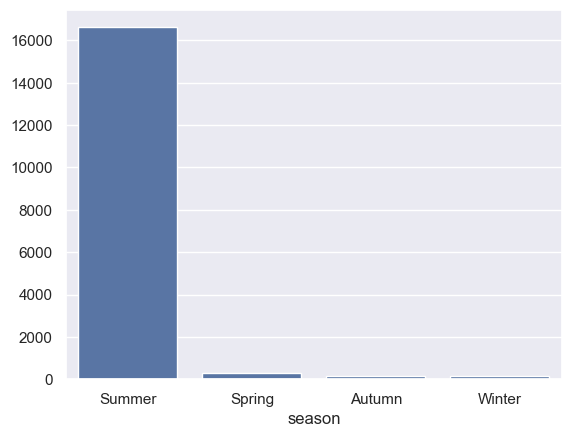

In [204]:
# Barchart visualization to show the distribution of orders in respect to seasons
non_missing_order_dates = data[data['has_order_date'] == 1]
sns.barplot(x=non_missing_order_dates['season'].value_counts().index, y=non_missing_order_dates['season'].value_counts().values)
plt.show()

In [207]:
non_missing_order_dates['season'].value_counts(normalize = True)

season
Summer    0.965319
Spring    0.017021
Autumn    0.009992
Winter    0.007668
Name: proportion, dtype: float64

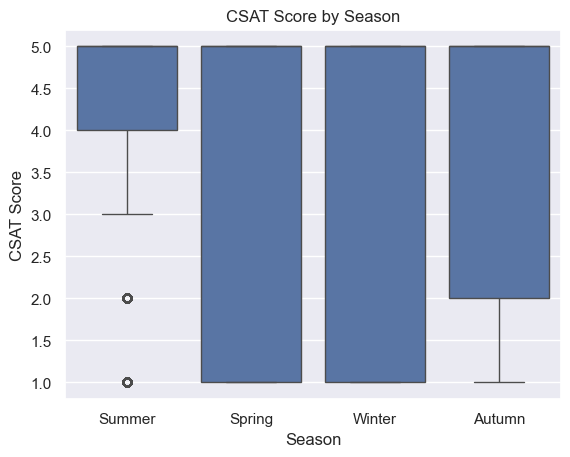

F-statistic: 6.248996997095181
p-value: 0.0003098060699155963
Reject null hypothesis: There is a significant difference between seasons.


In [216]:
# checking the relationship between season and csat score

sns.boxplot(x=non_missing_order_dates['season'], y=non_missing_order_dates['CSAT Score'])
plt.xlabel('Season')
plt.ylabel('CSAT Score')
plt.title('CSAT Score by Season')
plt.show()

# using anova test : one way anova

groups = [non_missing_order_dates[non_missing_order_dates['season'] == season]['CSAT Score'] for season in non_missing_order_dates['season'].unique()]

fstat , pval = f_oneway(*groups)
print("F-statistic:", fstat)
print("p-value:", pval)
if pval < 0.05:
    print("Reject null hypothesis: There is a significant difference between seasons.")
else:
    print("Fail to reject null hypothesis: No significant difference between seasons.")


Majority of the orders being reported with issue were purchased in the Summer Season

In [208]:
non_missing_order_dates[['order_year','season']].value_counts(normalize = True)

order_year  season
2023        Summer    0.963692
            Spring    0.016440
2022        Autumn    0.007668
2023        Winter    0.005751
            Autumn    0.002324
2022        Winter    0.001917
            Summer    0.001627
            Spring    0.000581
Name: proportion, dtype: float64

Majority of the orders being reported with issue were purchased in the Summer Season of 2023

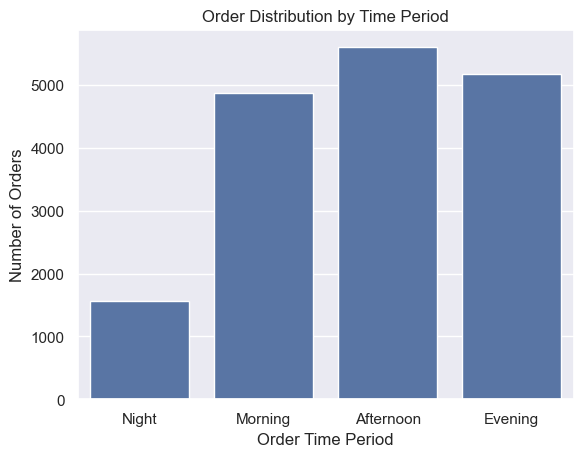

In [209]:
# distribution of order_time_period

sns.barplot(x=non_missing_order_dates['order_time_period'].value_counts().index, y=non_missing_order_dates['order_time_period'].value_counts().values)
plt.xlabel('Order Time Period')
plt.ylabel('Number of Orders')
plt.title('Order Distribution by Time Period')
plt.show()


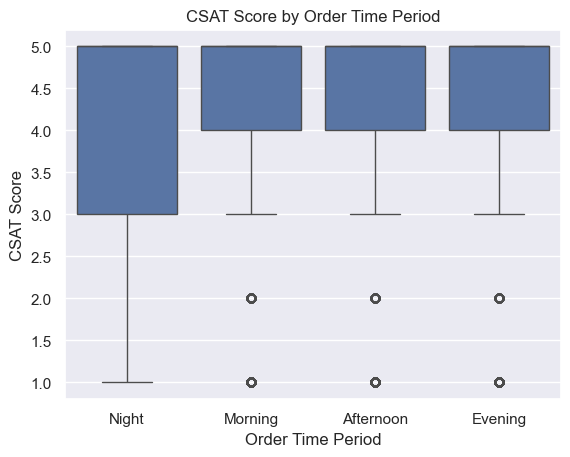

F-statistic: 0.8751280524341166
p-value: 0.45307830849426967
Fail to reject null hypothesis: No significant difference between order time periods.


In [217]:
# statistical test to check the relationship between order time period and csat score

sns.boxplot(x=non_missing_order_dates['order_time_period'], y=non_missing_order_dates['CSAT Score'])
plt.xlabel('Order Time Period')
plt.ylabel('CSAT Score')
plt.title('CSAT Score by Order Time Period')
plt.show()

# using anova test : one way anova

groups = [non_missing_order_dates[non_missing_order_dates['order_time_period'] == period]['CSAT Score'] for period in non_missing_order_dates['order_time_period'].unique()]

fstat , pval = f_oneway(*groups)
print("F-statistic:", fstat)
print("p-value:", pval)
if pval < 0.05:
    print("Reject null hypothesis: There is a significant difference between order time periods.")
else:
    print("Fail to reject null hypothesis: No significant difference between order time periods.")




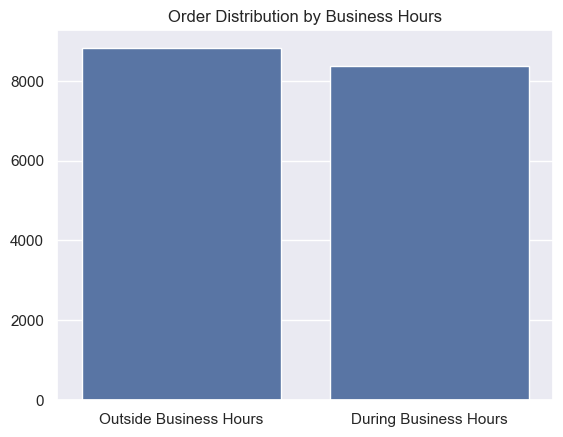

In [211]:
# barplot showing order distribution in respect to business hours

sns.barplot(x=non_missing_order_dates['is_business_hours'].value_counts().index, y=non_missing_order_dates['is_business_hours'].value_counts().values)
plt.xlabel('')
plt.xticks(ticks=[0, 1], labels=['Outside Business Hours', 'During Business Hours'])
plt.title('Order Distribution by Business Hours')
plt.show()

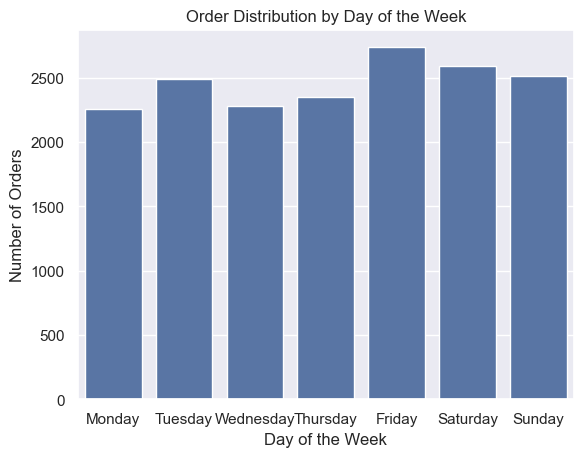

In [212]:
# Distribution of orders placed by Day of the week[Monday , Tuesday , Wednesday , Thursday , Friday , Saturday , Sunday]

sns.barplot(x=non_missing_order_dates['order_day_of_week'].value_counts().index, y=non_missing_order_dates['order_day_of_week'].value_counts().values)
plt.xlabel('Day of the Week')
plt.ylabel('Number of Orders')
plt.title('Order Distribution by Day of the Week')
plt.xticks(ticks=[0, 1, 2, 3, 4, 5, 6], labels=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.show()

In [213]:
data.columns

Index(['channel_name', 'category', 'Sub-category', 'Customer Remarks',
       'order_date_time', 'Issue_reported at', 'issue_responded',
       'Survey_response_Date', 'Customer_City', 'Product_category',
       'Item_price', 'connected_handling_time', 'Agent_name', 'Supervisor',
       'Manager', 'Tenure Bucket', 'Agent Shift', 'CSAT Score',
       'channel_Inbound', 'channel_Outcall', 'category_fe', 'category_encoded',
       'subcat_fe', 'subcat_te', 'remark_char_length', 'remark_word_count',
       'remark_sentence_count', 'cleaned_remarks', 'has_missing_remarks',
       'sentiment_polarity', 'sentiment_subjectivity', 'has_order_date',
       'order_date_time_imputed', 'order_year', 'order_month', 'order_day',
       'order_hour', 'order_day_of_week', 'order_day_of_year', 'is_weekend',
       'is_business_hours', 'order_time_period', 'season', 'time_to_issue'],
      dtype='object')

Data analysis and preprocessing of Issue Reported At feature

In [218]:
data['Issue_reported at'].isna().sum()

np.int64(0)

In [219]:
data['Issue_reported at'].dtypes

dtype('<M8[ns]')

In [220]:


# Basic temporal statistics
print("Issue Reporting Time Analysis:")
print(f"Earliest issue: {data['Issue_reported at'].min()}")
print(f"Latest issue: {data['Issue_reported at'].max()}")
print(f"Date range span: {(data['Issue_reported at'].max() - data['Issue_reported at'].min()).days} days")

Issue Reporting Time Analysis:
Earliest issue: 2023-07-28 20:42:00
Latest issue: 2023-08-31 23:58:00
Date range span: 34 days


In [222]:

# feature engineering : difference between issue reported date and issue responded date
data['IssueResponseTime'] = data['issue_responded'] - data['Issue_reported at']
# calculate the issueresponsetime in days
data['IssueResponseTimeDays'] = data['IssueResponseTime'].dt.days
# calculate the difference in HOURS
data['IssueResponseTimeHours'] = data['IssueResponseTime'].dt.total_seconds() / 3600


Overall Visualizations for the Analysis done till now

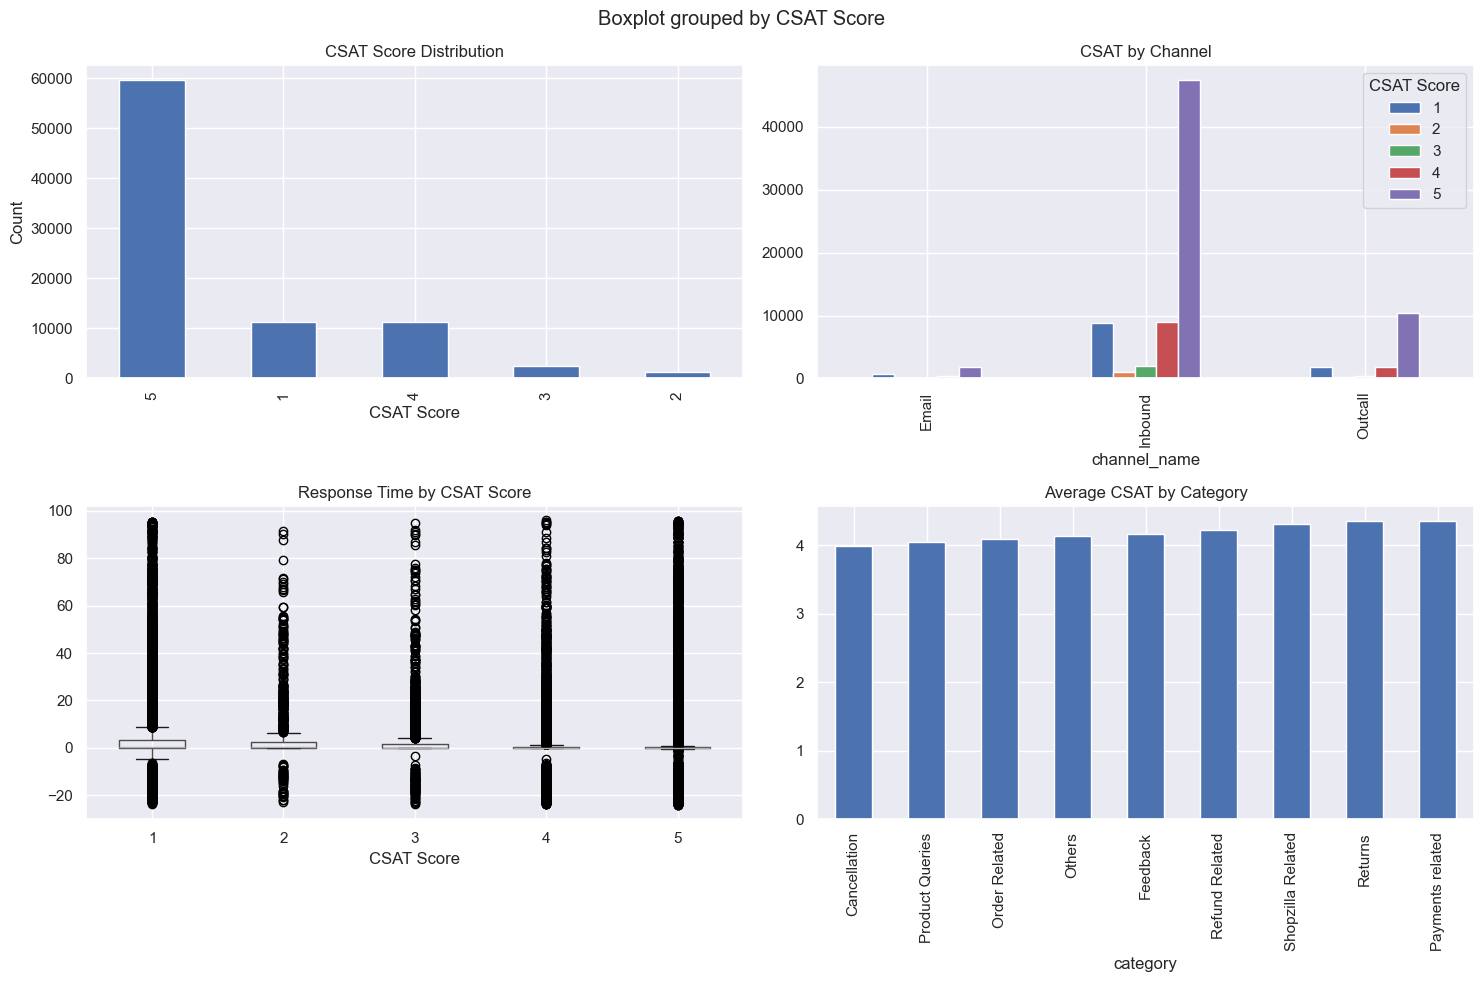

In [224]:

# 1. Comprehensive CSAT distribution analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# CSAT distribution
data['CSAT Score'].value_counts().plot(kind='bar', ax=axes[0,0])
axes[0,0].set_title('CSAT Score Distribution')
axes[0,0].set_ylabel("Count")
# CSAT by Channel
pd.crosstab(data['channel_name'], data['CSAT Score']).plot(kind='bar', ax=axes[0,1])
axes[0,1].set_title('CSAT by Channel')

# Response time vs CSAT
data.boxplot(column='IssueResponseTimeHours', by='CSAT Score', ax=axes[1,0])
axes[1,0].set_title('Response Time by CSAT Score')

# Category vs CSAT
category_csat = data.groupby('category')['CSAT Score'].mean().sort_values()
category_csat.plot(kind='bar', ax=axes[1,1])
axes[1,1].set_title('Average CSAT by Category')

plt.tight_layout()
plt.show()


In [ ]:
data['IssueResponseTimeHours'].describe()

# how is the Time taken to respond to issues (IssueResponseTimeHours) negative ?

count    85907.000000
mean         2.281443
std          9.875476
min        -23.950000
25%          0.033333
50%          0.083333
75%          0.583333
max         95.966667
Name: IssueResponseTimeHours, dtype: float64

In [ ]:
# Checking for negative response times
negative_response_times = data[data['IssueResponseTimeHours'] < 0]
print("Negative Response Times:")
negative_response_times

# It is due to the different formats of Issue_reported at and issue_responded features 

Negative Response Times:


,channel_name,category,Sub-category,Customer Remarks,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score,channel_Inbound,channel_Outcall,category_fe,category_encoded,subcat_fe,subcat_te,remark_char_length,remark_word_count,remark_sentence_count,cleaned_remarks,has_missing_remarks,sentiment_polarity,sentiment_subjectivity,has_order_date,order_date_time_imputed,order_year,order_month,order_day,order_hour,order_day_of_week,order_day_of_year,is_weekend,is_business_hours,order_time_period,season,time_to_issue,IssueResponseTime,IssueResponseTimeDays,IssueResponseTimeHours
74172,Inbound,Refund Related,Others,<Missing_Remark>,2023-07-24 07:33:00,2023-08-28 16:07:00,2023-08-28,28-Aug-23,BHAGALPUR,LifeStyle,323.0,NaN,Steven Wall,Zoe Yamamoto,Emily Chen,>90,Afternoon,5,True,False,0.052964,4.226813,0.000989,4.181052,-1,-1,-1,<Missing_Remark>,1,0.0,0.0,1,2023-07-24 07:33:00.000000,2023,7,24,7,0,205,0,0,Morning,Summer,-16.116667,-1 days +07:53:00,-1,-16.116667
74173,Outcall,Returns,Reverse Pickup Enquiry,<Missing_Remark>,NaT,2023-08-28 16:56:00,2023-08-28,28-Aug-23,NaN,NaN,NaN,NaN,Brittney Key,Mia Yamamoto,Jennifer Nguyen,On Job Training,Morning,3,False,True,0.513311,4.346350,0.260619,4.184999,-1,-1,-1,<Missing_Remark>,1,0.0,0.0,0,2023-08-10 22:49:26.619031,2023,8,10,22,3,222,0,0,Evening,Summer,-16.933333,-1 days +07:04:00,-1,-16.933333
74174,Inbound,Payments related,Online Payment Issues,<Missing_Remark>,NaT,2023-08-28 20:14:00,2023-08-28,28-Aug-23,NaN,NaN,NaN,NaN,Brian Koch,Ethan Tan,Jennifer Nguyen,On Job Training,Evening,5,True,False,0.027087,4.354534,0.012560,4.390104,-1,-1,-1,<Missing_Remark>,1,0.0,0.0,0,2023-08-11 02:07:26.619031,2023,8,11,2,4,223,0,0,Night,Summer,-20.233333,-1 days +03:46:00,-1,-20.233333
74175,Inbound,Payments related,Others,<Missing_Remark>,NaT,2023-08-28 14:37:00,2023-08-28,28-Aug-23,NaN,NaN,NaN,NaN,Ronnie Romero,Aiden Patel,John Smith,>90,Morning,5,True,False,0.027087,4.354534,0.000664,4.214070,-1,-1,-1,<Missing_Remark>,1,0.0,0.0,0,2023-08-10 20:30:26.619031,2023,8,10,20,3,222,0,0,Evening,Summer,-14.616667,-1 days +09:23:00,-1,-14.616667
74176,Inbound,Returns,Return request,<Missing_Remark>,NaT,2023-08-28 23:26:00,2023-08-28,28-Aug-23,NaN,NaN,NaN,NaN,Ann English,Olivia Suzuki,Olivia Tan,On Job Training,Morning,5,True,False,0.513311,4.346350,0.099212,4.616809,-1,-1,-1,<Missing_Remark>,1,0.0,0.0,0,2023-08-11 05:19:26.619031,2023,8,11,5,4,223,0,0,Night,Summer,-23.433333,-1 days +00:34:00,-1,-23.433333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77566,Outcall,Payments related,Others,So glad,NaT,2023-08-28 13:25:00,2023-08-28,28-Aug-23,NaN,NaN,NaN,NaN,Tammy Gould,Ava Wong,Jennifer Nguyen,On Job Training,Morning,5,False,True,0.027087,4.354534,0.000198,4.185167,8,2,1,glad,0,0.5,1.0,0,2023-08-10 19:18:26.619031,2023,8,10,19,3,222,0,0,Evening,Summer,-13.416667,-1 days +10:35:00,-1,-13.416667
77567,Outcall,Returns,Return request,<Missing_Remark>,NaT,2023-08-28 18:09:00,2023-08-28,28-Aug-23,NaN,NaN,NaN,NaN,Cathy Harris,Charlotte Suzuki,William Kim,On Job Training,Morning,5,False,True,0.513311,4.346350,0.099212,4.616809,-1,-1,-1,<Missing_Remark>,1,0.0,0.0,0,2023-08-11 00:02:26.619031,2023,8,11,0,4,223,0,0,Night,Summer,-18.150000,-1 days +05:51:00,-1,-18.150000
77568,Outcall,Returns,Reverse Pickup Enquiry,Good,NaT,2023-08-28 22:20:00,2023-08-28,28-Aug-23,NaN,NaN,NaN,NaN,Jessica Cook,Ethan Tan,Michael Lee,>90,Evening,4,False,True,0.513311,4.346350,0.260619,4.184999,4,1,1,good,0,0.7,0.6,0,2023-08-11 04:13:26.619031,2023,8,11,4,4,223,0,0,Night,Summer,-22.333333,-1 days +01:40:00,-1,-22.333333
77569,Inbound,Order Related,Order status enquiry,Your delivery agents are not doing good work...,NaT,2023-08-28 14:38:00,2023-08-28,28-Aug-23,N

In [231]:
# fixing the cause of negative IssueResponseTimeHours
data['issue_responded'] = data['issue_responded'] + pd.Timedelta(hours=23, minutes=59, seconds=59)
# Recalculating the IssueResponseTime,IssueResponseTimeHours and IssueResponseTimeDays
data['IssueResponseTime'] = data['issue_responded'] - data['Issue_reported at']
data['IssueResponseTimeHours'] = data['IssueResponseTime'].dt.total_seconds() / 3600
data['IssueResponseTimeDays'] = data['IssueResponseTime'].dt.days


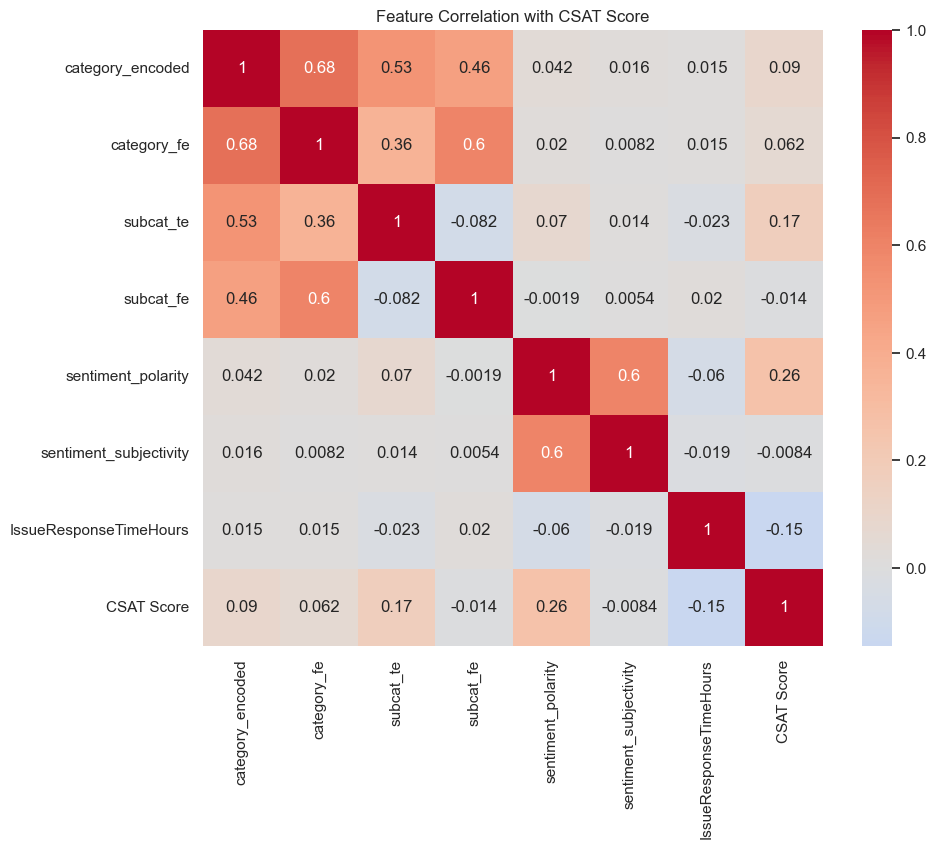

In [236]:
# Correlation analysis
numerical_features = ['category_encoded', 'category_fe', 'subcat_te', 'subcat_fe', 
                     'sentiment_polarity', 'sentiment_subjectivity',
                     'IssueResponseTimeHours']

correlation_matrix = data[numerical_features + ['CSAT Score']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlation with CSAT Score')
plt.show()




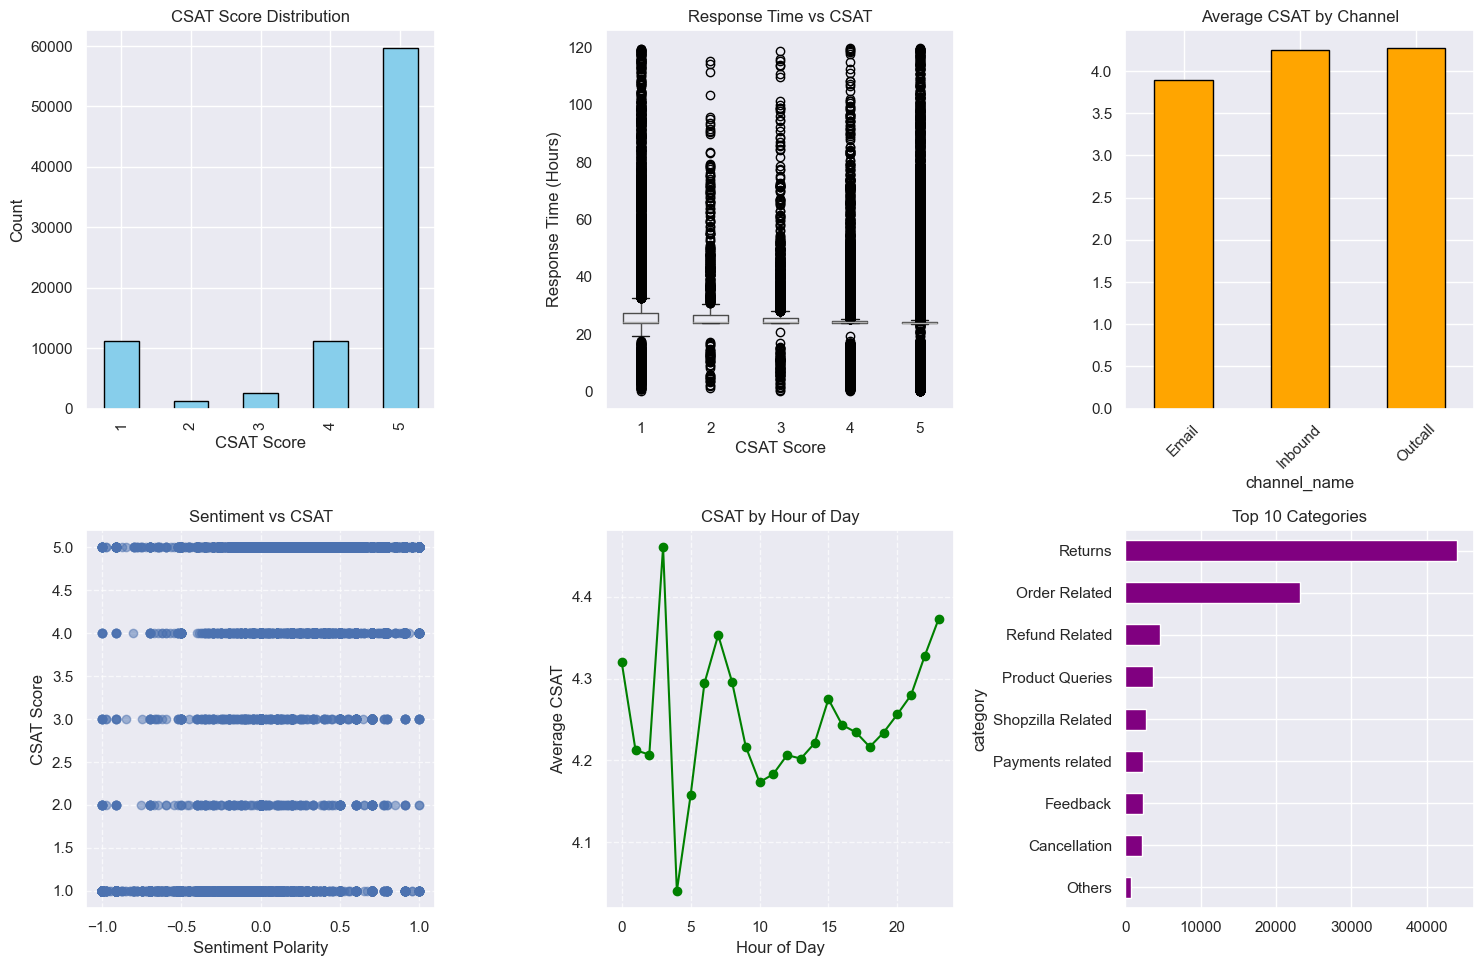

In [237]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# 1. CSAT Score Distribution
data['CSAT Score'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title('CSAT Score Distribution')
axes[0].set_xlabel('CSAT Score')
axes[0].set_ylabel('Count')

# 2. Response Time Analysis
data.boxplot(column='IssueResponseTimeHours',
             by='CSAT Score', ax=axes[1], grid=False)
axes[1].set_title('Response Time vs CSAT')
axes[1].set_xlabel('CSAT Score')
axes[1].set_ylabel('Response Time (Hours)')
fig.suptitle("")  # Remove default super title from boxplot

# 3. Channel Performance
channel_csat = data.groupby('channel_name')['CSAT Score'].mean()
channel_csat.plot(kind='bar', ax=axes[2], color='orange', edgecolor='black')
axes[2].set_title('Average CSAT by Channel')
axes[2].tick_params(axis='x', rotation=45)

# 4. Sentiment vs CSAT
axes[3].scatter(data['sentiment_polarity'], data['CSAT Score'], alpha=0.5)
axes[3].set_xlabel('Sentiment Polarity')
axes[3].set_ylabel('CSAT Score')
axes[3].set_title('Sentiment vs CSAT')
axes[3].grid(True, linestyle='--', alpha=0.7)

# 5. Temporal Patterns
data['Issue_hour'] = pd.to_datetime(data['Issue_reported at']).dt.hour
hourly_csat = data.groupby('Issue_hour')['CSAT Score'].mean()
hourly_csat.plot(ax=axes[4], marker='o', color='green')
axes[4].set_title('CSAT by Hour of Day')
axes[4].set_xlabel('Hour of Day')
axes[4].set_ylabel('Average CSAT')
axes[4].grid(True, linestyle='--', alpha=0.7)

# 6. Category Distribution
data['category'].value_counts().head(10).plot(kind='barh', ax=axes[5], color='purple')
axes[5].set_title('Top 10 Categories')
axes[5].invert_yaxis()

plt.tight_layout()
plt.show()


In [238]:
# Feature Engineering for Issue_reported at
import pandas as pd
from datetime import datetime

def create_issue_reporting_features(data):
    # Ensure datetime format
    data['Issue_reported at'] = pd.to_datetime(data['Issue_reported at'], format='%d/%m/%Y %H:%M')
    
    # Extract temporal components
    data['reported_year'] = data['Issue_reported at'].dt.year
    data['reported_month'] = data['Issue_reported at'].dt.month
    data['reported_hour'] = data['Issue_reported at'].dt.hour
    data['reported_day_of_week'] = data['Issue_reported at'].dt.dayofweek
    
    # Business-oriented features
    data['reported_at_weekend'] = data['reported_day_of_week'].isin([5, 6]).astype(int)
    data['reported_at_business_hour'] = data['reported_hour'].between(9, 17).astype(int)
    
    # Time period categories
    def get_time_period(hour):
        if 6 <= hour < 12: return 'Morning'
        elif 12 <= hour < 18: return 'Afternoon'
        elif 18 <= hour < 24: return 'Evening'
        else: return 'Night'
    
    data['reported_time_period'] = data['reported_hour'].apply(get_time_period)
    
    # Seasonal categories
    def get_season(month):
        if month in [12, 1, 2]: return 'Winter'
        elif month in [3, 4, 5]: return 'Spring'
        elif month in [6, 7, 8]: return 'Summer'
        else: return 'Autumn'
    
    data['reported_season'] = data['reported_month'].apply(get_season)
    
    return data

data = create_issue_reporting_features(data)

In [240]:
data.head()

,channel_name,category,Sub-category,Customer Remarks,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score,channel_Inbound,channel_Outcall,category_fe,category_encoded,subcat_fe,subcat_te,remark_char_length,remark_word_count,remark_sentence_count,cleaned_remarks,has_missing_remarks,sentiment_polarity,sentiment_subjectivity,has_order_date,order_date_time_imputed,order_year,order_month,order_day,order_hour,order_day_of_week,order_day_of_year,is_weekend,is_business_hours,order_time_period,season,time_to_issue,IssueResponseTime,IssueResponseTimeDays,IssueResponseTimeHours,Issue_hour,reported_year,reported_month,reported_hour,reported_day_of_week,reported_at_weekend,reported_at_business_hour,reported_time_period,reported_season
0,Outcall,Product Queries,Others,<Missing_Remark>,NaT,2023-08-01 11:13:00,2023-08-02 11:46:59,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5,False,True,0.042977,4.039816,0.000268,4.185167,-1,-1,-1,<Missing_Remark>,1,0.0,0.0,0,2023-07-14 17:06:26.619031,2023,7,14,17,4,195,0,1,Afternoon,Summer,0.566667,1 days 00:33:59,1,24.566389,11,2023,8,11,1,0,1,Morning,Summer
1,Outcall,Product Queries,Product Specific Information,<Missing_Remark>,NaT,2023-08-01 12:52:00,2023-08-02 12:53:59,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5,False,True,0.042977,4.039816,0.041778,4.013627,-1,-1,-1,<Missing_Remark>,1,0.0,0.0,0,2023-07-14 18:45:26.619031,2023,7,14,18,4,195,0,0,Afternoon,Summer,0.033333,1 days 00:01:59,1,24.033056,12,2023,8,12,1,0,1,Afternoon,Summer
2,Inbound,Order Related,Installation/demo,<Missing_Remark>,NaT,2023-08-01 20:16:00,2023-08-02 20:37:59,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5,True,False,0.270234,4.096059,0.047912,3.865802,-1,-1,-1,<Missing_Remark>,1,0.0,0.0,0,2023-07-15 02:09:26.619031,2023,7,15,2,5,196,1,0,Night,Summer,0.366667,1 days 00:21:59,1,24.366389,20,2023,8,20,1,0,0,Evening,Summer
3,Inbound,Returns,Reverse Pickup Enquiry,<Missing_Remark>,NaT,2023-08-01 20:56:00,2023-08-02 21:15:59,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5,True,False,0.513311,4.346350,0.260619,4.191937,-1,-1,-1,<Missing_Remark>,1,0.0,0.0,0,2023-07-15 02:49:26.619031,2023,7,15,2,5,196,1,0,Night,Summer,0.333333,1 days 00:19:59,1,24.333056,20,2023,8,20,1,0,0,Evening,Summer
4,Inbound,Cancellation,Not Needed,<Missing_Remark>,NaT,2023-08-01 10:30:00,2023-08-02 10:31:59,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5,True,False,0.025749,3.990506,0.022350,3.921189,-1,-1,-1,<Missing_Remark>,1,0.0,0.0,0,2023-07-14 16:23:26.619031,2023,7,14,16,4,195,0,1,Afternoon,Summer,0.033333,1 days 00:01:59,1,24.033056,10,2023,8,10,1,0,1,Morning,Summer


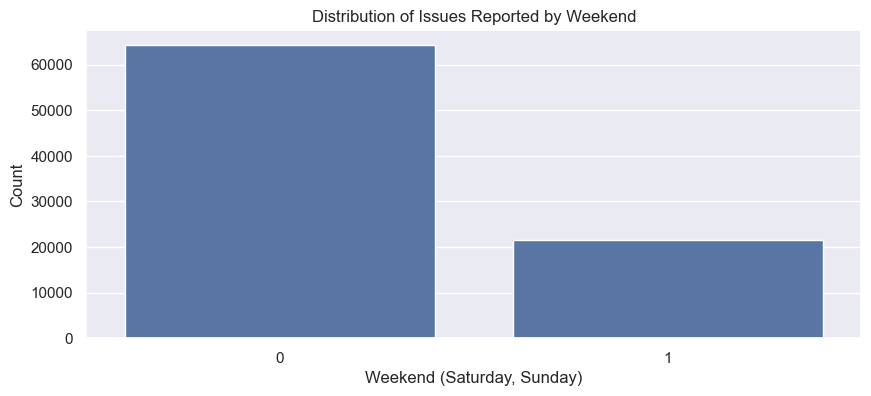

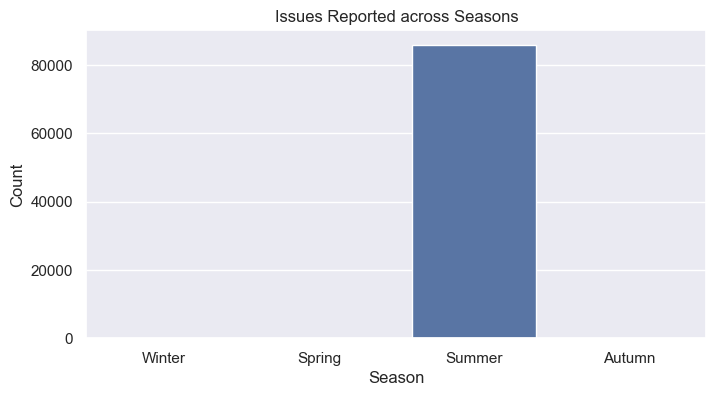

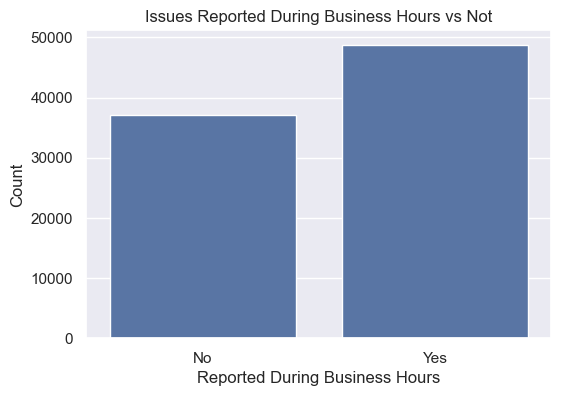

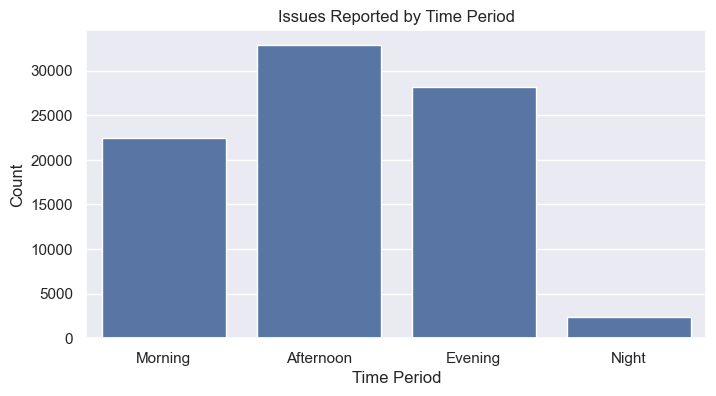

In [241]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of reports across weekends
plt.figure(figsize=(10,4))
sns.countplot(x='reported_at_weekend', data=data)
plt.title('Distribution of Issues Reported by Weekend')
plt.xlabel('Weekend (Saturday, Sunday)')
plt.ylabel('Count')
plt.show()

# Distribution by season
plt.figure(figsize=(8,4))
sns.countplot(x='reported_season', data=data, order=['Winter', 'Spring', 'Summer', 'Autumn'])
plt.title('Issues Reported across Seasons')
plt.xlabel('Season')
plt.ylabel('Count')
plt.show()

# Report counts by Business Hour vs Non-Business Hour
plt.figure(figsize=(6,4))
sns.countplot(x='reported_at_business_hour', data=data)
plt.title('Issues Reported During Business Hours vs Not')
plt.xlabel('Reported During Business Hours')
plt.ylabel('Count')
plt.xticks([0,1], ['No', 'Yes'])
plt.show()

# Distribution of reports by Time Period
plt.figure(figsize=(8,4))
sns.countplot(x='reported_time_period', data=data, order=['Morning', 'Afternoon', 'Evening', 'Night'])
plt.title('Issues Reported by Time Period')
plt.xlabel('Time Period')
plt.ylabel('Count')
plt.show()


In [242]:
# Dropping Survey_response_Date column . It is just the date of the feedback given by the customer.

data.drop(columns=['Survey_response_Date'], inplace=True)

In [243]:
# Customer City Column

# data['Customer_City']
print("Number of missing values in customer city")
print(data['Customer_City'].isnull().sum())
missing_percentage = data['Customer_City'].isnull().mean() * 100
print(f"Missing Value Percentage: {missing_percentage:.2f}%")



Number of missing values in customer city
68828
Missing Value Percentage: 80.12%


In [244]:
print(f"Number of unique customer cities: {data['Customer_City'].nunique()}")
data[['Customer_City' , 'CSAT Score']]

Number of unique customer cities: 1782


,Customer_City,CSAT Score
0,NaN,5
1,NaN,5
2,NaN,5
3,NaN,5
4,NaN,5
...,...,...
85902,NaN,4
85903,NaN,5
85904,NaN,5
85905,NaN,4


In [245]:
data.groupby('Customer_City')['CSAT Score'].mean().sort_values(ascending=False)

Customer_City
ADOOR          5.0
ZUARINAGAR     5.0
ZIRA           5.0
ADRA           5.0
WARUD          5.0
              ... 
ALLAGADDA      1.0
AHMEDGARH      1.0
YERRAGUNTLA    1.0
Wada           1.0
WELLINGTON     1.0
Name: CSAT Score, Length: 1782, dtype: float64

In [246]:
data[data['Customer_City'].isnull()]['CSAT Score'].mean()

np.float64(4.310658452955193)

In [247]:
# Fill missing customer city with 'Unknown'
data['Customer_City'].fillna('Unknown', inplace=True)
# Checking the correlation between customer city and CSAT score using kruskal-wallis test
from scipy.stats import kruskal
import pandas as pd
import numpy as np

# Kruskal-Wallis test for Customer_City vs CSAT Score
print("=== KRUSKAL-WALLIS TEST: Customer_City vs CSAT Score ===")

# Remove missing cities first
city_data = data.dropna(subset=['Customer_City'])
city_data = city_data[city_data['Customer_City'] != "Unknown"]

# Create groups for each city
city_groups = [group['CSAT Score'].values for name, group in city_data.groupby('Customer_City')]

# Perform Kruskal-Wallis test
h_stat, p_value = kruskal(*city_groups)

print(f"Kruskal-Wallis H-statistic: {h_stat:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"Result: {'Significant relationship' if p_value < 0.05 else 'No significant relationship'}")
print(f"Effect size (eta-squared): {(h_stat - len(city_groups) + 1) / (len(city_data) - len(city_groups)):.4f}")



=== KRUSKAL-WALLIS TEST: Customer_City vs CSAT Score ===
Kruskal-Wallis H-statistic: 1948.1635
P-value: 0.003178
Result: Significant relationship
Effect size (eta-squared): 0.0109


In [248]:
# The feature is important predictor for Csat score therefore we will keep it . But we will reduce the number of categories into 5 sections based on the mean csat score for the city.
city_mean_csat_scores = data.groupby('Customer_City')['CSAT Score'].mean().reset_index()
def city_map(score):
    if score <= 1:
        return 1
    elif score <= 2:
        return 2
    elif score <= 3:
        return 3
    elif score <= 4:
        return 4
    else:
        return 5

city_mean_csat_scores['city_category'] = city_mean_csat_scores['CSAT Score'].apply(city_map)
city_mean_csat_scores



,Customer_City,CSAT Score,city_category
0,ABOHAR,3.500000,4
1,ABU ROAD,4.333333,5
2,ADILABAD,3.142857,4
3,ADIPUR,4.222222,5
4,ADONI,2.333333,3
...,...,...,...
1778,ZAHEERABAD,1.000000,1
1779,ZAMANIA,3.000000,3
1780,ZIRA,5.000000,5
1781,ZIRAKPUR,3.909091,4


In [249]:
# creating city_category in data
data['city_category'] = data["Customer_City"].map(city_mean_csat_scores.set_index('Customer_City')['city_category'])
data.head()

,channel_name,category,Sub-category,Customer Remarks,order_date_time,Issue_reported at,issue_responded,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score,channel_Inbound,channel_Outcall,category_fe,category_encoded,subcat_fe,subcat_te,remark_char_length,remark_word_count,remark_sentence_count,cleaned_remarks,has_missing_remarks,sentiment_polarity,sentiment_subjectivity,has_order_date,order_date_time_imputed,order_year,order_month,order_day,order_hour,order_day_of_week,order_day_of_year,is_weekend,is_business_hours,order_time_period,season,time_to_issue,IssueResponseTime,IssueResponseTimeDays,IssueResponseTimeHours,Issue_hour,reported_year,reported_month,reported_hour,reported_day_of_week,reported_at_weekend,reported_at_business_hour,reported_time_period,reported_season,city_category
0,Outcall,Product Queries,Others,<Missing_Remark>,NaT,2023-08-01 11:13:00,2023-08-02 11:46:59,Unknown,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5,False,True,0.042977,4.039816,0.000268,4.185167,-1,-1,-1,<Missing_Remark>,1,0.0,0.0,0,2023-07-14 17:06:26.619031,2023,7,14,17,4,195,0,1,Afternoon,Summer,0.566667,1 days 00:33:59,1,24.566389,11,2023,8,11,1,0,1,Morning,Summer,5
1,Outcall,Product Queries,Product Specific Information,<Missing_Remark>,NaT,2023-08-01 12:52:00,2023-08-02 12:53:59,Unknown,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5,False,True,0.042977,4.039816,0.041778,4.013627,-1,-1,-1,<Missing_Remark>,1,0.0,0.0,0,2023-07-14 18:45:26.619031,2023,7,14,18,4,195,0,0,Afternoon,Summer,0.033333,1 days 00:01:59,1,24.033056,12,2023,8,12,1,0,1,Afternoon,Summer,5
2,Inbound,Order Related,Installation/demo,<Missing_Remark>,NaT,2023-08-01 20:16:00,2023-08-02 20:37:59,Unknown,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5,True,False,0.270234,4.096059,0.047912,3.865802,-1,-1,-1,<Missing_Remark>,1,0.0,0.0,0,2023-07-15 02:09:26.619031,2023,7,15,2,5,196,1,0,Night,Summer,0.366667,1 days 00:21:59,1,24.366389,20,2023,8,20,1,0,0,Evening,Summer,5
3,Inbound,Returns,Reverse Pickup Enquiry,<Missing_Remark>,NaT,2023-08-01 20:56:00,2023-08-02 21:15:59,Unknown,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5,True,False,0.513311,4.346350,0.260619,4.191937,-1,-1,-1,<Missing_Remark>,1,0.0,0.0,0,2023-07-15 02:49:26.619031,2023,7,15,2,5,196,1,0,Night,Summer,0.333333,1 days 00:19:59,1,24.333056,20,2023,8,20,1,0,0,Evening,Summer,5
4,Inbound,Cancellation,Not Needed,<Missing_Remark>,NaT,2023-08-01 10:30:00,2023-08-02 10:31:59,Unknown,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5,True,False,0.025749,3.990506,0.022350,3.921189,-1,-1,-1,<Missing_Remark>,1,0.0,0.0,0,2023-07-14 16:23:26.619031,2023,7,14,16,4,195,0,1,Afternoon,Summer,0.033333,1 days 00:01:59,1,24.033056,10,2023,8,10,1,0,1,Morning,Summer,5


Analysis and preprocessing of Product_category

In [250]:
# Product category unique values 

data['Product_category'].unique()

array([nan, 'LifeStyle', 'Electronics', 'Mobile', 'Home Appliences',
       'Furniture', 'Home', 'Books & General merchandise', 'GiftCard',
       'Affiliates'], dtype=object)

In [251]:
# Analysis and preprocessing of Product_category

data['Product_category'].value_counts(dropna=False)

Product_category
NaN                            68711
Electronics                     4706
LifeStyle                       4118
Books & General merchandise     3323
Mobile                          1758
Home                            1328
Home Appliences                 1300
Furniture                        471
Affiliates                       166
GiftCard                          26
Name: count, dtype: int64

In [252]:
print("The missing percentage values in product category : ")
print(data['Product_category'].isnull().mean()*100)

The missing percentage values in product category : 
79.98300487736738


In [253]:
# Replace the missing null values with "Unknown" Product category


data['Product_category'].fillna("Unknown" , inplace = True )

In [254]:
data['Product_category'].value_counts()

Product_category
Unknown                        68711
Electronics                     4706
LifeStyle                       4118
Books & General merchandise     3323
Mobile                          1758
Home                            1328
Home Appliences                 1300
Furniture                        471
Affiliates                       166
GiftCard                          26
Name: count, dtype: int64

In [255]:
data['Product_category'].nunique()

10

In [256]:
# Check the relation btw product category and csat score

# ANOVA Test (primary test)
categories = data['Product_category'].unique()
groups = [data[data['Product_category'] == cat]['CSAT Score'] 
          for cat in categories if len(data[data['Product_category'] == cat]) > 0]

f_stat, p_value_anova = f_oneway(*groups)

print(f"\n=== ANOVA RESULTS ===")
print(f"F-statistic: {f_stat:.4f}")
print(f"p-value: {p_value_anova:.6f}")
print(f"Significant: {'YES - Include in model!' if p_value_anova < 0.05 else 'NO - Consider excluding'}")

print("The ANOVA test suggests that the Mean CSAT Scores differs by Product Category.")


# The ANOVA test suggests that the Mean CSAT Scores differs by Product Category.


# Chi-Square Test
contingency = pd.crosstab(data['Product_category'], data['CSAT Score'])
print(f"\n=== CONTINGENCY TABLE ===")
print(contingency)

chi2, p_chi2, dof, expected = chi2_contingency(contingency)
print(f"\n=== CHI-SQUARE RESULTS ===")
print(f"Chi-square statistic: {chi2:.4f}")
print(f"p-value: {p_chi2:.6f}")
print(f"Significant: {'YES' if p_chi2 < 0.05 else 'NO'}")

print("The Chi-Square test of Independence suggests that the Product Category and CSAT Score are strongly related.")


=== ANOVA RESULTS ===
F-statistic: 123.8031
p-value: 0.000000
Significant: YES - Include in model!
The ANOVA test suggests that the Mean CSAT Scores differs by Product Category.

=== CONTINGENCY TABLE ===
CSAT Score                      1    2     3     4      5
Product_category                                         
Affiliates                     23    3     3    25    112
Books & General merchandise   584   74   115   433   2117
Electronics                   852   85   167   593   3009
Furniture                     136    7    17    51    260
GiftCard                       11    0     0     2     13
Home                          269   24    37   166    832
Home Appliences               350   22    40   141    747
LifeStyle                     654   73   131   571   2689
Mobile                        486   44    58   188    982
Unknown                      7865  951  1990  9049  48856

=== CHI-SQUARE RESULTS ===
Chi-square statistic: 1182.1624
p-value: 0.000000
Significant: YES
The

The statistical tests conducted (ANOVA and Chi-Square) indicate a significant relationship between Product Category and CSAT Score.


In [257]:
# checking the correlation strength btw product category and CSAT score

# Label encode the product category (simple numeric conversion)
data['product_category_encoded'] = data['Product_category'].astype('category').cat.codes

# Pearson correlation
correlation = data['product_category_encoded'].corr(data['CSAT Score'])
print(f"Pearson correlation: {correlation:.3f}")

# Spearman correlation (non-parametric)
spearman_corr = data[['product_category_encoded', 'CSAT Score']].corr(method='spearman').iloc[0,1]
print(f"Spearman correlation: {spearman_corr:.3f}")

Pearson correlation: 0.076
Spearman correlation: 0.083


Very weak correlation between product category and CSAT score.

In [ ]:
# Target Mean Encoding 
from scipy.stats import spearmanr

# Target mean encoding
mean_table = data.groupby('Product_category')['CSAT Score'].mean()

# Map back to rows
data['product_cat_te'] = data['Product_category'].map(mean_table)

# Pearson correlation
correlation = data['product_cat_te'].corr(data['CSAT Score'])
print(f"Pearson correlation: {correlation:.3f}")

# Spearman correlation
spearman_corr, _ = spearmanr(data['product_cat_te'], data['CSAT Score'])
print(f"Spearman correlation: {spearman_corr:.3f}")


Pearson correlation: 0.113
Spearman correlation: 0.089


In [ ]:
# One hot encoding the product category

product_dummies = pd.get_dummies(data['Product_category'], prefix='product', dtype=int, drop_first=True)
print(product_dummies.shape)

# concatenate
data = pd.concat([data, product_dummies], axis=1)


(85907, 9)

Analysis and Preprocessing of Item_price column.

In [267]:
# missing value analysis for Item_price
print(f"Missing : {data['Item_price'].isnull().sum()}")
print(f"Missing Percentage : {data['Item_price'].isnull().mean() * 100}%")

Missing : 68701
Missing Percentage : 79.97136438241354%


In [268]:
data['Item_price'].describe()

count     17206.000000
mean       5660.774846
std       12825.728411
min           0.000000
25%         392.000000
50%         979.000000
75%        2699.750000
max      164999.000000
Name: Item_price, dtype: float64

📊 Key Insights

80% missing values (68,701 out of 85,907 records)

High variance: Mean ₹5,661 vs Median ₹979 (right-skewed)

Wide range: ₹0 to ₹164,999

Extreme outliers: Some prices exceed ₹50,000



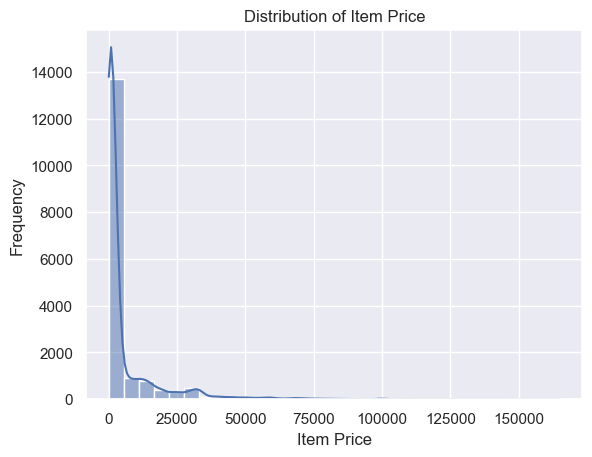

In [269]:

# Create the distribution for Item_price using distplot
sns.histplot(data['Item_price'], kde=True, bins=30)
plt.title('Distribution of Item Price')
plt.xlabel('Item Price')
plt.ylabel('Frequency')
plt.show()

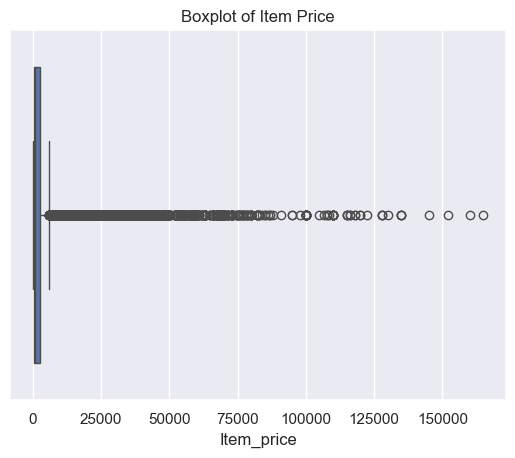

In [270]:
# Boxplot of Item Price
sns.boxplot(x=data['Item_price'])
plt.title('Boxplot of Item Price')
plt.show()


Presence of outliers in high number

Missing values analysis

channel_name distribution
channel_name
Inbound    54259
Outcall    12568
Email       1874
Name: count, dtype: int64
category distribution
category
Returns              35855
Order Related        16931
Product Queries       3675
Refund Related        3382
Shopzilla Related     2772
Payments related      2278
Feedback              1756
Cancellation          1410
Others                 642
Name: count, dtype: int64
Sub-category distribution
Sub-category
Reverse Pickup Enquiry              18519
Return request                       6801
Order status enquiry                 5392
Delayed                              3713
Installation/demo                    3637
Product Specific Information         3584
Fraudulent User                      3310
Others                               2257
Missing                              2155
Refund Enquiry                       2067
Wrong                                2006
General Enquiry                      1895
UnProfessional Behaviour             1756

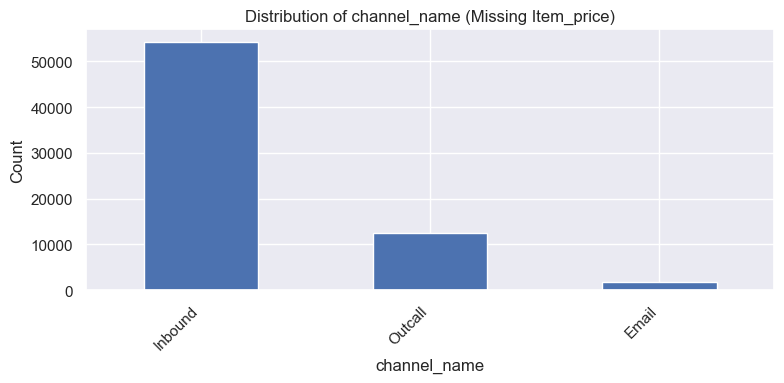

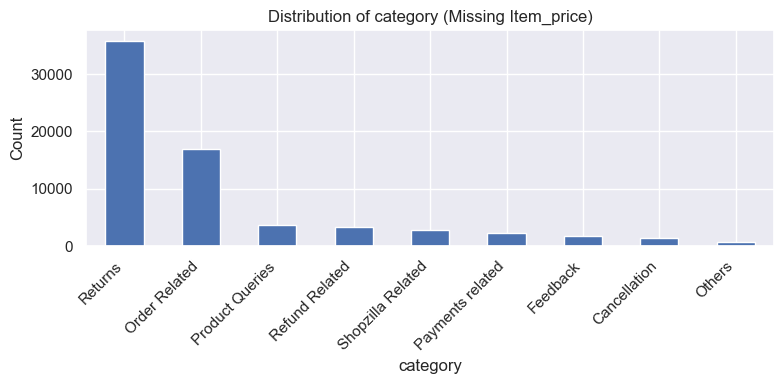

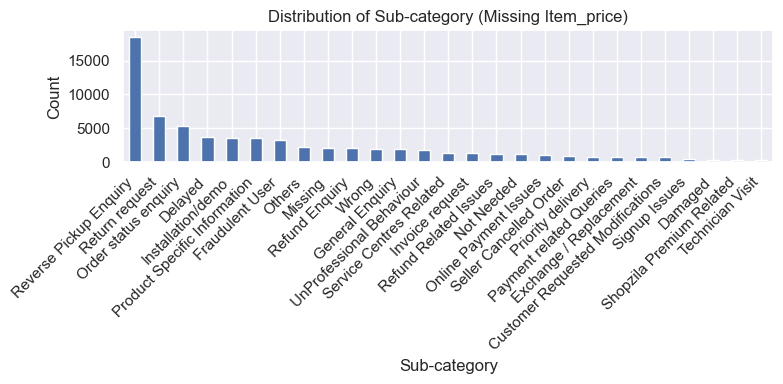

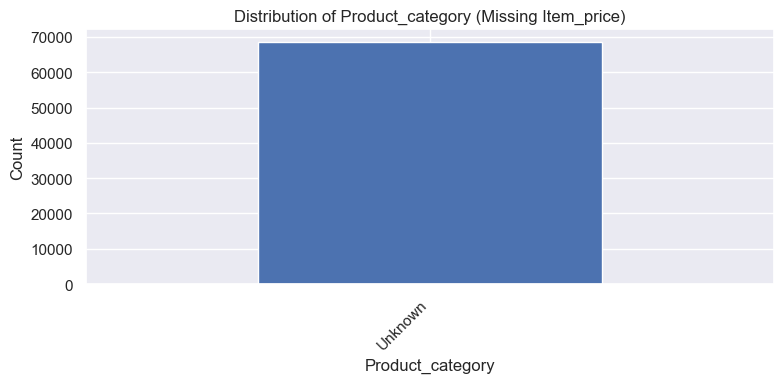

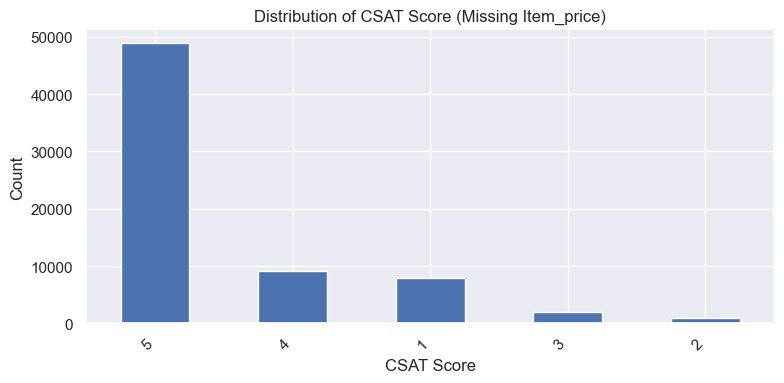

In [272]:
missing_item_price_data = data[data['Item_price'].isna()]
print("channel_name distribution")
print(missing_item_price_data["channel_name"].value_counts(dropna=False))
print("category distribution")
print(missing_item_price_data["category"].value_counts(dropna=False))
print("Sub-category distribution")
print(missing_item_price_data["Sub-category"].value_counts(dropna=False))
print("Customer Remarks distribution")
print(missing_item_price_data["Customer Remarks"].value_counts(dropna=False))
print("Customer_City distribution")
print(missing_item_price_data["Customer_City"].value_counts(dropna=False))
print("Product_category distribution")
print(missing_item_price_data["Product_category"].value_counts(dropna=False))
print("CSAT Score distribution")
print(missing_item_price_data["CSAT Score"].value_counts(dropna=False))

# visualize
import matplotlib.pyplot as plt

# List of categorical columns to check
cols = ["channel_name", "category", "Sub-category", 
         "Product_category", "CSAT Score"]

# Plot bar charts
for col in cols:
    plt.figure(figsize=(8,4))
    missing_item_price_data[col].value_counts(dropna=False).plot(kind='bar')
    plt.title(f"Distribution of {col} (Missing Item_price)")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


In [273]:
data['Item_price'].describe()

count     17206.000000
mean       5660.774846
std       12825.728411
min           0.000000
25%         392.000000
50%         979.000000
75%        2699.750000
max      164999.000000
Name: Item_price, dtype: float64

In [274]:




# missing_price_indicator
data['has_item_price'] = data['Item_price'].notna().astype(int)

# Zero price indicator  
data['is_zero_price'] = (data['Item_price'] == 0).astype(int)

#  Price categories
def categorize_price(price):
    if pd.isna(price):
        return 'Missing'
    elif price == 0:
        return 'Free'
    elif price <= 500:
        return 'Low'
    elif price <= 2000:
        return 'Medium'
    elif price <= 10000:
        return 'High'
    else:
        return 'Premium'

data['price_category'] = data['Item_price'].apply(categorize_price)



# 4. Outlier detection

Q1 = data['Item_price'].quantile(0.25)
Q3 = data['Item_price'].quantile(0.75)
IQR = Q3 - Q1
outlier_threshold = Q3 + 1.5 * IQR

data['is_price_outlier'] = (
    (data['Item_price'] > outlier_threshold) & 
    (data['Item_price'].notna())
).astype(int)


# SMART IMPUTATION
print("\n=== IMPUTATION ===")

# Calculate median by Product_category
median_by_category = data.groupby('Product_category')['Item_price'].median()
print("Median prices by Product Category:")
print(median_by_category)

# Impute with category-specific medians
data['item_price_imputed'] = data['Item_price'].copy()

for category in data['Product_category'].unique():
    if category != "Unknown" and category in median_by_category:
        mask = (data['Product_category'] == category) & (data['Item_price'].isna())
        data.loc[mask, 'item_price_imputed'] = median_by_category[category]

# For "Unknown" Product_category, we will randomly bootstrap from real prices
# For missing prices with unknown category
mask_unknown_cat = (data['Product_category']=="Unknown") & (data['Item_price'].isna())


sampled_prices = data['Item_price'].dropna().sample(
    n=mask_unknown_cat.sum(),
    replace=True,
    random_state=42
).values

data.loc[mask_unknown_cat, 'item_price_imputed'] = sampled_prices


print("Median for each product category after Imputation:")
print(data.groupby('Product_category')['item_price_imputed'].median())


=== IMPUTATION ===
Median prices by Product Category:
Product_category
Affiliates                       157.0
Books & General merchandise      334.0
Electronics                     1199.0
Furniture                       7299.0
GiftCard                        2850.0
Home                             413.5
Home Appliences                 7994.5
LifeStyle                        581.0
Mobile                         18999.0
Unknown                         1078.0
Name: Item_price, dtype: float64
Median for each product category after Imputation:
Product_category
Affiliates                       157.0
Books & General merchandise      334.0
Electronics                     1199.0
Furniture                       7299.0
GiftCard                        2850.0
Home                             413.5
Home Appliences                 7994.5
LifeStyle                        581.0
Mobile                         18999.0
Unknown                          969.0
Name: item_price_imputed, dtype: float64


<Axes: xlabel='item_price_imputed', ylabel='Count'>

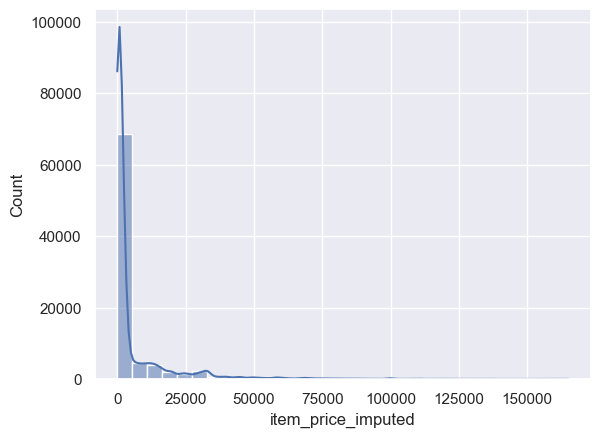

In [276]:
# distribution check for item_price_imputed

sns.histplot(data['item_price_imputed'] , kde = True , bins = 30)

<Axes: xlabel='item_price_imputed', ylabel='Count'>

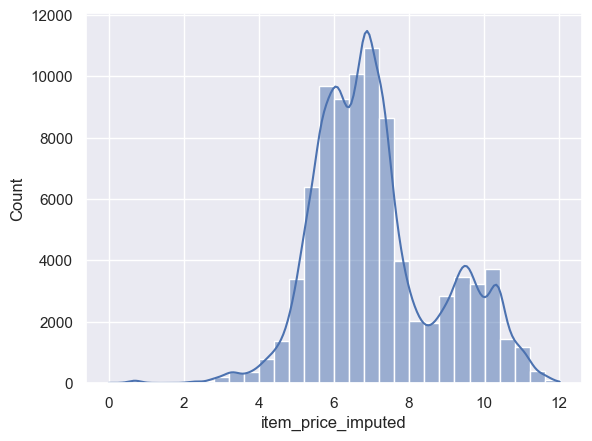

In [279]:
item_price_log = np.log1p(data['item_price_imputed'])
sns.histplot(item_price_log,kde=True , bins = 30)

In [280]:
data['item_price_log'] = item_price_log

In [283]:
data['price_category'].value_counts()

price_category
Missing    68701
Medium      6621
Low         5697
Premium     2739
High        2148
Free           1
Name: count, dtype: int64

In [291]:
# ordinal encoding the price_category
data['price_category_encoded'] = data['price_category'].map({
    'Missing': -1,
    "Free": -1,
    'Low': 0,
    'Medium': 1,
    'High': 2,
    'Premium': 3
})


Analysis and preprocessing of connected_handling_time 

In [292]:

print("Descriptive statistics for connected_handling_time:")
print(data['connected_handling_time'].describe())

Descriptive statistics for connected_handling_time:
count     242.000000
mean      462.400826
std       246.295037
min         0.000000
25%       293.000000
50%       427.000000
75%       592.250000
max      1986.000000
Name: connected_handling_time, dtype: float64


In [293]:
# Missing values
print("Missing values in connected_handling_time:",data['connected_handling_time'].isna().sum())
print("Percentage of missing values in connected_handling_time:",data['connected_handling_time'].isna().mean() * 100)

Missing values in connected_handling_time: 85665
Percentage of missing values in connected_handling_time: 99.71830002211695


Why So Much Missing Data:
Email tickets don't require "connected" time

Self-service queries have no agent interaction

Automated responses aren't "handled" by humans

In [294]:
# zero second connected time records

len(np.where(data['connected_handling_time'] == 0)[0])

# Two records with zero as connected_handling_time

2

In [295]:
# mean connected_handling time

mean_connected_handling_time = data['connected_handling_time'].dropna().mean().round(2)
print("Mean connected_handling_time:", mean_connected_handling_time)
print("Mean connected_handling_time in Minutes:", (mean_connected_handling_time / 60).round(2))

Mean connected_handling_time: 462.4
Mean connected_handling_time in Minutes: 7.71


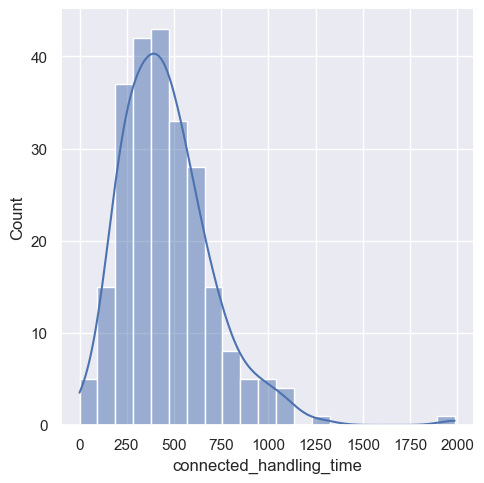

In [296]:
# checking the distribution 
sns.displot(data['connected_handling_time'].dropna() , kde = True)

# a little right skewed .

In [297]:
# mising_indicator for missing connected_handling_time

data["missing_connected_handling_time_flag"] = data['connected_handling_time'].isna().astype(int)


In [298]:
# checking relationship with the target feature

not_missing = data[data['connected_handling_time'].notna()]
# One way anova

mean_groups = [not_missing[not_missing["CSAT Score"] == score]['connected_handling_time'] for score in not_missing['CSAT Score'].unique()]

f_stat , anova_p = f_oneway(*mean_groups)
print(f"ANOVA test p-value: {anova_p}")

ANOVA test p-value: 0.6703327958436732


The result signifies that Failed to Reject the Null Hypothesis : The mean connected_handling_time is equal across different CSAT Score groups.

In [299]:
# Kruskal Walis test
from scipy.stats import kruskal

not_missing = data[data['connected_handling_time'].notna()]
groups = [
    not_missing[not_missing["CSAT Score"] == score]['connected_handling_time']
    for score in sorted(not_missing['CSAT Score'].unique())
]
stat, p = kruskal(*groups)
print(f"Kruskal-Wallis test statistic: {stat:.4f}, p-value: {p:.4f}")


Kruskal-Wallis test statistic: 5.6892, p-value: 0.2236


Hypotheses:
Null Hypothesis (H₀): The distribution of connected_handling_time is the same across all CSAT Score groups. (All groups are from populations with the same distribution.)

Alternative Hypothesis (H₁): There is at least one CSAT Score group where the distribution of connected_handling_time is different from the others.



Interpretation:

The p-value is far above the typical cutoff of 0.05.

Conclusion: You fail to reject the null hypothesis. This means there is no statistically significant difference in the distribution of connected_handling_time across different CSAT Score groups.

In [300]:
from scipy.stats import spearmanr

not_missing = data[data['connected_handling_time'].notna()]
corr, p = spearmanr(
    not_missing['connected_handling_time'],
    not_missing['CSAT Score']
)
print(f"Spearman correlation: {corr:.4f}, p-value: {p:.4f}")


Spearman correlation: 0.1138, p-value: 0.0773


Interpretation:

Spearman's rho 0.1138 is a very weak positive relationship (if any) between handling time and CSAT Score.

The p-value is greater than 0.05, so the result is not statistically significant.

Conclusion: You fail to reject the null hypothesis. There is no evidence for a monotonic relationship between the two variables.

Hypotheses:
Null Hypothesis (H₀): There is no monotonic association between connected_handling_time and CSAT Score (correlation = 0).

Alternative Hypothesis (H₁): There is a monotonic association (correlation ≠ 0).

ALL THE TESTS SHOW INSUFFICIENT SIGNIFICANCE OF CONNECTED_HANDLING_TIME WITH RESPECT TO CSAT SCORE.THERE WE WONT DO FURTHER ANALYSIS AND PREPROCESSING OF THE FEATURE FOR MAKING IT MODEL READY. RATHER WE WILL JUST USE MISSING INDICATOR OF THE FEATURE AS THE FINAL REPRESENTATION.


In [ ]:
# Outlier Detection

Q1 = data['connected_handling_time'].quantile(0.25)
Q3 = data['connected_handling_time'].quantile(0.75)
IQR = Q3 - Q1
outlier_threshold_high = Q3 + 1.5 * IQR

print(f"Upper outlier threshold: {outlier_threshold_high}")
# Potential outliers
outliers = data[data['connected_handling_time'] > outlier_threshold_high]
print(f"Number of outliers: {len(outliers)}")


Upper outlier threshold: 1041.125
Number of outliers: 6


In [302]:
# Time-based categories
def categorize_handling_time(time):
    if pd.isna(time):
        return 'No_Interaction'
    elif time == 0:
        return 'No_Interaction'
    elif time <= 300:
        return 'Quick'      # ≤5 minutes
    elif time <= 600:
        return 'Normal'     # 5-10 minutes
    elif time <= 1200:
        return 'Long'       # 10-20 minutes
    else:
        return 'Very_Long'  # >20 minutes

data['handling_time_category'] = data['connected_handling_time'].apply(categorize_handling_time)

In [303]:
data['handling_time_category'].value_counts()

handling_time_category
No_Interaction    85667
Normal              121
Quick                62
Long                 55
Very_Long             2
Name: count, dtype: int64

In [304]:
from scipy.stats import kruskal

# Filter data to include only non-missing CSAT scores and handling_time_category
valid_data = data

# Create list of CSAT scores grouped by handling_time_category
groups = [
    valid_data[valid_data['handling_time_category'] == category]['CSAT Score']
    for category in valid_data['handling_time_category'].unique()
]

# Perform Kruskal-Wallis test
stat, p_value = kruskal(*groups)

print(f"Kruskal-Wallis test statistic: {stat:.4f}")
print(f"p-value: {p_value:.4f}")

# Interpretation:
if p_value < 0.05:
    print("Significant differences exist between CSAT scores across handling_time categories.")
else:
    print("No significant differences found between CSAT scores across handling_time categories.")


Kruskal-Wallis test statistic: 9.9957
p-value: 0.0405
Significant differences exist between CSAT scores across handling_time categories.


In [176]:
data.handling_time_category.value_counts()

handling_time_category
No_Interaction    85665
Normal              121
Quick                62
Long                 55
ZeroTime              2
Very_Long             2
Name: count, dtype: int64

In [305]:
# Ordinal Encoder function for handling time categories
def encoder(category):
    return category.map({
        'No_Interaction': 0,
        'Quick': 1,
        'Normal': 2,
        'Long': 3,
        'Very_Long': 4
    })

data['handling_time_category_encoded'] = encoder(data['handling_time_category'])

In [310]:
# dropping Agent_name , Supervisor , Manager columns
data.drop(columns=['Agent_name', 'Supervisor', 'Manager'], axis = 1,inplace=True)


In [311]:
data['Tenure Bucket'].value_counts(dropna = False)

Tenure Bucket
>90                30660
On Job Training    25523
31-60              11665
0-30               11318
61-90               6741
Name: count, dtype: int64

In [312]:
# Ordinal encoding tenure bucket column
# Convert to experience level (0-4)
tenure_mapping = {
    'On Job Training': 0,  # Least experienced
    '0-30': 1, 
    '31-60': 2,
    '61-90': 3,
    '>90': 4  # Most experienced
}
data['tenure_encoded'] = data['Tenure Bucket'].map(tenure_mapping)


In [313]:
data['Agent Shift'].value_counts(dropna = False)

Agent Shift
Morning      41426
Evening      33677
Afternoon     5840
Split         3648
Night         1316
Name: count, dtype: int64

In [ ]:
# Different shifts handle different customer moods/issue types
shift_dummies = pd.get_dummies(data['Agent Shift'], prefix='shift' , drop_first=True)
# concatenate
data = pd.concat([data, shift_dummies], axis=1)


CSAT Score Feature

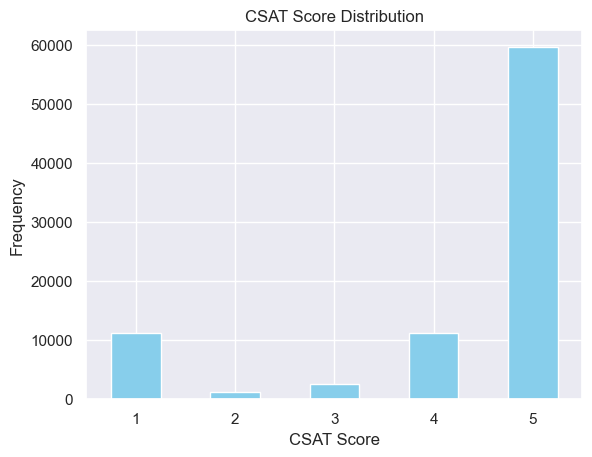

In [315]:
# CSAT Score Distribution
data['CSAT Score'].value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.title('CSAT Score Distribution')
plt.xlabel('CSAT Score')
plt.ylabel('Frequency')
plt.xticks(rotation=0)
plt.show()

In [316]:
data['CSAT Score'].value_counts(normalize=True)

CSAT Score
5    0.693971
1    0.130723
4    0.130595
3    0.029776
2    0.014935
Name: proportion, dtype: float64

High class imbalance is present. 69 percent of the responses are in the '5' category.

In [319]:
data.columns

Index(['channel_name', 'category', 'Sub-category', 'Customer Remarks',
       'order_date_time', 'Issue_reported at', 'issue_responded',
       'Customer_City', 'Product_category', 'Item_price',
       'connected_handling_time', 'Tenure Bucket', 'Agent Shift', 'CSAT Score',
       'channel_Inbound', 'channel_Outcall', 'category_fe', 'category_encoded',
       'subcat_fe', 'subcat_te', 'remark_char_length', 'remark_word_count',
       'remark_sentence_count', 'cleaned_remarks', 'has_missing_remarks',
       'sentiment_polarity', 'sentiment_subjectivity', 'has_order_date',
       'order_date_time_imputed', 'order_year', 'order_month', 'order_day',
       'order_hour', 'order_day_of_week', 'order_day_of_year', 'is_weekend',
       'is_business_hours', 'order_time_period', 'season', 'time_to_issue',
       'IssueResponseTime', 'IssueResponseTimeDays', 'IssueResponseTimeHours',
       'Issue_hour', 'reported_year', 'reported_month', 'reported_hour',
       'reported_day_of_week', 'reported_

In [321]:
model_data = data[['CSAT Score' ,'channel_Inbound', 'channel_Outcall', 'category_fe', 'category_encoded',
       'subcat_fe', 'subcat_te', 'remark_char_length', 'remark_word_count',
       'remark_sentence_count','has_missing_remarks',
       'sentiment_polarity', 'sentiment_subjectivity', 'has_order_date',
       'IssueResponseTimeHours','time_to_issue','IssueResponseTimeHours','reported_time_period', 'reported_season','city_category','has_item_price', 'is_zero_price','is_price_outlier','item_price_log','price_category_encoded','missing_connected_handling_time_flag','handling_time_category_encoded', 'tenure_encoded']]
# X_embeddings
# product_dummies
# shift_dummies

In [322]:
model_data.shape

(85907, 28)

In [324]:
model_data.isnull().sum()

CSAT Score                              0
channel_Inbound                         0
channel_Outcall                         0
category_fe                             0
category_encoded                        0
subcat_fe                               0
subcat_te                               0
remark_char_length                      0
remark_word_count                       0
remark_sentence_count                   0
has_missing_remarks                     0
sentiment_polarity                      0
sentiment_subjectivity                  0
has_order_date                          0
IssueResponseTimeHours                  0
time_to_issue                           0
IssueResponseTimeHours                  0
reported_time_period                    0
reported_season                         0
city_category                           0
has_item_price                          0
is_zero_price                           0
is_price_outlier                        0
item_price_log                    

In [325]:
model_data.head()

,CSAT Score,channel_Inbound,channel_Outcall,category_fe,category_encoded,subcat_fe,subcat_te,remark_char_length,remark_word_count,remark_sentence_count,has_missing_remarks,sentiment_polarity,sentiment_subjectivity,has_order_date,IssueResponseTimeHours,time_to_issue,IssueResponseTimeHours,reported_time_period,reported_season,city_category,has_item_price,is_zero_price,is_price_outlier,item_price_log,price_category_encoded,missing_connected_handling_time_flag,handling_time_category_encoded,tenure_encoded
0,5,False,True,0.042977,4.039816,0.000268,4.185167,-1,-1,-1,1,0.0,0.0,0,24.566389,0.566667,24.566389,Morning,Summer,5,0,0,0,7.170120,-1,1,0,0
1,5,False,True,0.042977,4.039816,0.041778,4.013627,-1,-1,-1,1,0.0,0.0,0,24.033056,0.033333,24.033056,Afternoon,Summer,5,0,0,0,8.013012,-1,1,0,4
2,5,True,False,0.270234,4.096059,0.047912,3.865802,-1,-1,-1,1,0.0,0.0,0,24.366389,0.366667,24.366389,Evening,Summer,5,0,0,0,7.495542,-1,1,0,0
3,5,True,False,0.513311,4.346350,0.260619,4.191937,-1,-1,-1,1,0.0,0.0,0,24.333056,0.333333,24.333056,Evening,Summer,5,0,0,0,9.692767,-1,1,0,4
4,5,True,False,0.025749,3.990506,0.022350,3.921189,-1,-1,-1,1,0.0,0.0,0,24.033056,0.033333,24.033056,Morning,Summer,5,0,0,0,7.479300,-1,1,0,1


In [334]:
# reported_time_period      
# reported_season                                   

model_data['reported_time_period'].value_counts()
# one hot encoding the reported_time_period
reported_time_dummies = pd.get_dummies(model_data, columns=['reported_time_period'], drop_first=True,prefix='reported_time')

print(model_data['reported_season'].value_counts())
print("reported_season has only one category , we wont use it for model training")


reported_season
Summer    85907
Name: count, dtype: int64
reported_season has only one category , we wont use it for model training


In [335]:
model_data.drop(['reported_season'], axis=1, inplace=True)

In [336]:
model_data.head()

,CSAT Score,channel_Inbound,channel_Outcall,category_fe,category_encoded,subcat_fe,subcat_te,remark_char_length,remark_word_count,remark_sentence_count,has_missing_remarks,sentiment_polarity,sentiment_subjectivity,has_order_date,IssueResponseTimeHours,time_to_issue,IssueResponseTimeHours,reported_time_period,city_category,has_item_price,is_zero_price,is_price_outlier,item_price_log,price_category_encoded,missing_connected_handling_time_flag,handling_time_category_encoded,tenure_encoded
0,5,False,True,0.042977,4.039816,0.000268,4.185167,-1,-1,-1,1,0.0,0.0,0,24.566389,0.566667,24.566389,Morning,5,0,0,0,7.170120,-1,1,0,0
1,5,False,True,0.042977,4.039816,0.041778,4.013627,-1,-1,-1,1,0.0,0.0,0,24.033056,0.033333,24.033056,Afternoon,5,0,0,0,8.013012,-1,1,0,4
2,5,True,False,0.270234,4.096059,0.047912,3.865802,-1,-1,-1,1,0.0,0.0,0,24.366389,0.366667,24.366389,Evening,5,0,0,0,7.495542,-1,1,0,0
3,5,True,False,0.513311,4.346350,0.260619,4.191937,-1,-1,-1,1,0.0,0.0,0,24.333056,0.333333,24.333056,Evening,5,0,0,0,9.692767,-1,1,0,4
4,5,True,False,0.025749,3.990506,0.022350,3.921189,-1,-1,-1,1,0.0,0.0,0,24.033056,0.033333,24.033056,Morning,5,0,0,0,7.479300,-1,1,0,1


In [ ]:
# save the processed data
# In your data_analysis.ipynb, add this cell:
model_data.to_csv('../data/model_data_processed.csv', index=False)

# adding X_embeddings to model_data.First convert model_data to matrix
data_matrix = model_data.values
# concatenate data_matrix with X_embeddings
final_data = np.concatenate((data_matrix, X_embeddings), axis=1)
# save it
np.save('../data/final_data.npy', final_data)
